# 1.Package Import

In [1]:
from bmovie_code import gen_table1_subj_info
from pynwb import NWBHDF5IO
from pathlib import Path
import numpy as np
import pandas as pd

from new_code import data_summary, load_data_into_pds, load_data_into_dict, slicer, label, feature, decompose, fusion, new_fusion

import pickle
from scipy.signal import detrend

In [2]:
%load_ext autoreload
%autoreload 2

# 2. Global file location (need to specify your own path)

In [3]:
NWB_DIR="/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files"
BIDS_DIR="/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/bids_files"

In [4]:
gen_table1_subj_info.main(
    nwb_input_dir=NWB_DIR,
    bids_datadir=BIDS_DIR
)

# 3. Load labels and data

In [3]:
# labels
with open("../assets/annotations/short_faceannots.pkl", "rb") as f:
    face_annots = pickle.load(f)

type(face_annots)
# print(list(face_annots.items())[:10])

path = "../assets/annotations/scenecut_info.csv"
scenecut_info = pd.read_csv(path)

print(scenecut_info.head())

   scene_id  shot_start_fr  shot_start_t  shot_dur_t  location cut_type  \
0       1.0            1.0          0.00        4.72  backyard      cut   
1       1.0          119.0          4.72       10.28  backyard      cut   
2       1.0          376.0         15.00        1.72  backyard      cut   
3       1.0          419.0         16.72        2.36  backyard      cut   
4       1.0          478.0         19.08        2.64  backyard      cut   

   cut_dur_t  cut_dur_fr  
0        0.0           0  
1        0.0           0  
2        0.0           0  
3        0.0           0  
4        0.0           0  


In [4]:
df_face_note = label.build_face_feature_df(face_annots, target_id="Jacky")
print(df_face_note.tail())

        frame_key  frame_idx  movie_time  n_faces  total_face_area  \
9373  frame_11898      11898      475.92        2      35470.00073   
9374  frame_11899      11899      475.96        2      35470.00073   
9375  frame_11900      11900      476.00        2      35470.00073   
9376  frame_11901      11901      476.04        2      35470.00073   
9377  frame_11902      11902      476.08        2      35470.00073   

      max_face_area  Jacky_present  any_front_face dominant_emotion  \
9373   24058.686485              0               1        surprised   
9374   24058.686485              0               1        surprised   
9375   24058.686485              0               1        surprised   
9376   24058.686485              0               1        surprised   
9377   24058.686485              0               1        surprised   

      emo_afraid  emo_angry  emo_happy  emo_neutral  emo_surprised  
9373       False      False      False        False           True  
9374       Fal

## 3.1 Label Check

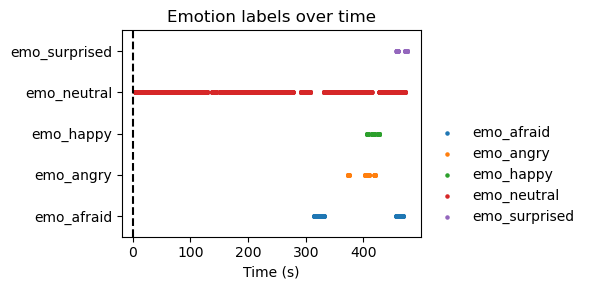

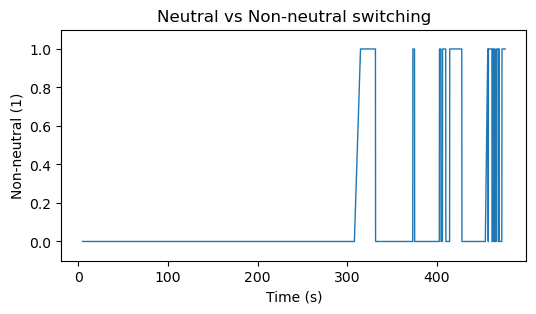

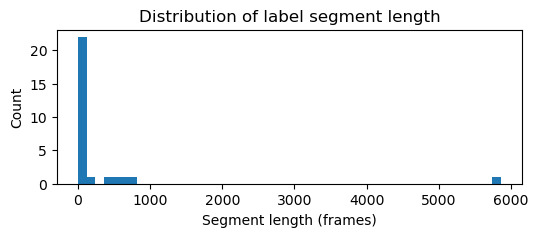

median: 47.0
short (<5 frames): 0.0


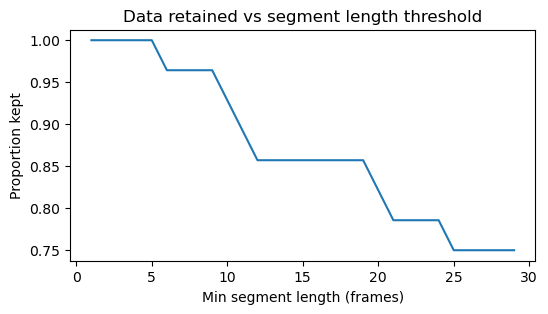

In [8]:
import matplotlib.pyplot as plt

emo_cols = [
    "emo_afraid",
    "emo_angry",
    "emo_happy",
    "emo_neutral",
    "emo_surprised"
]

t = df_face_note["movie_time"].values

# ===================================
# face emotion label check
# ===================================
plt.figure(figsize=(6, 3))

for i, col in enumerate(emo_cols):
    y = df_face_note[col].astype(int) * (i + 1)
    plt.scatter(t, y, s=5, label=col)

plt.axvline(0, color="black", linestyle="--")
plt.yticks(range(1, len(emo_cols)+1), emo_cols)
plt.ylim(0.5, len(emo_cols)+0.5)
plt.xlabel("Time (s)")
plt.title("Emotion labels over time")
plt.legend(bbox_to_anchor=(1.0,0), loc="lower left", frameon=False)
plt.tight_layout()
plt.show()

# ===================================
# face emotion switching
# ===================================
is_non_neutral = ~df_face_note["emo_neutral"]

plt.figure(figsize=(6, 3))
plt.plot(t, is_non_neutral.astype(int), linewidth=1)

plt.xlabel("Time (s)")
plt.ylabel("Non-neutral (1)")
plt.title("Neutral vs Non-neutral switching")
plt.ylim(-0.1, 1.1)
plt.show()

# ===================================
# distribution check
# ===================================
labels = df_face_note["dominant_emotion"].values

segments = []
start = 0

for i in range(1, len(labels)):
    if labels[i] != labels[i-1]:
        segments.append((labels[i-1], start, i-1))
        start = i

segments.append((labels[-1], start, len(labels)-1))

lengths = [end - start + 1 for (_, start, end) in segments]

plt.figure(figsize=(6, 2))
plt.hist(lengths, bins=50)
plt.xlabel("Segment length (frames)")
plt.ylabel("Count")
plt.title("Distribution of label segment length")
plt.show()

print("median:", np.median(lengths))
print("short (<5 frames):", np.mean(np.array(lengths) < 5))

# ===================================
# screen check
# ===================================

lengths = np.array(lengths)

thresholds = np.arange(1, 30)
proportion = [(lengths >= th).mean() for th in thresholds]

plt.figure(figsize=(6, 3))
plt.plot(thresholds, proportion)
plt.xlabel("Min segment length (frames)")
plt.ylabel("Proportion kept")
plt.title("Data retained vs segment length threshold")
plt.show()

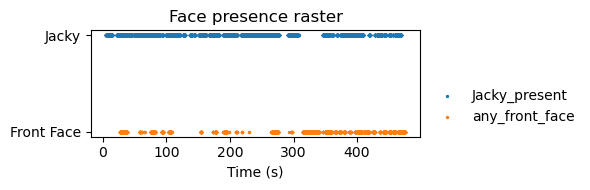

In [7]:
import matplotlib.pyplot as plt

t = df_face_note["movie_time"].values

jacky = df_face_note["Jacky_present"].astype(int).values
front = df_face_note["any_front_face"].astype(int).values

plt.figure(figsize=(6, 2))

plt.scatter(t[jacky == 1], [1]*np.sum(jacky==1), s=2, label="Jacky_present")
plt.scatter(t[front == 1], [0]*np.sum(front==1), s=2, label="any_front_face")

plt.yticks([0, 1], ["Front Face", "Jacky"])
plt.xlabel("Time (s)")
plt.title("Face presence raster")
plt.legend(bbox_to_anchor=(1.0,0), loc="lower left", frameon=False)
plt.tight_layout()
plt.show()

In [9]:
nwb_path = load_data_into_pds.find_nwb_file_for_subject(NWB_DIR, "CS41")
print("Using:", nwb_path)

io = NWBHDF5IO(str(nwb_path), "r", load_namespaces=True)
nwb = io.read()

print("\n=== acquisition keys ===")
print(list(nwb.acquisition.keys()))

print("\n=== processing modules ===")
print(list(nwb.processing.keys()))

for mod_name, mod in nwb.processing.items():
    print(f"\n--- processing[{mod_name}] keys ---")
    try:
        print(list(mod.data_interfaces.keys()))
    except Exception as e:
        print("cannot list data_interfaces:", e)

print("\n=== stimulus keys ===")
print(list(getattr(nwb, "stimulus", {}).keys()))

print("\n=== intervals ===")
print(list(getattr(nwb, "intervals", {}).keys()))

io.close()

Using: /Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb

=== acquisition keys ===
['events_ttl', 'experiment_ids']

=== processing modules ===
['behavior', 'ecephys']

--- processing[behavior] keys ---
['Blink', 'EyeTracking', 'Fixation', 'PupilTracking', 'Saccade']

--- processing[ecephys] keys ---
['LFP_macro', 'LFP_micro']

=== stimulus keys ===
['movieframe_time']

=== intervals ===
['trials']


In [10]:
from pynwb import NWBHDF5IO
io = NWBHDF5IO("/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb", "r", load_namespaces=True)
nwb = io.read()

ece = nwb.processing["ecephys"]
print("LFP_macro electrical_series keys:", list(ece["LFP_macro"].electrical_series.keys()))
print("LFP_micro electrical_series keys:", list(ece["LFP_micro"].electrical_series.keys()))

beh = nwb.processing["behavior"]
print("EyeTracking spatial_series keys:", list(beh["EyeTracking"].spatial_series.keys()))
print("PupilTracking time_series keys:", list(beh["PupilTracking"].time_series.keys()))

io.close()

LFP_macro electrical_series keys: ['ElectricalSeries']
LFP_micro electrical_series keys: ['ElectricalSeries']
EyeTracking spatial_series keys: ['SpatialSeries']
PupilTracking time_series keys: ['TimeSeries']


In [11]:
sub_nums = [41, 42, 43, 44, 47, 48, 49, 51, 53, 54, 55, 56, 57, 58, 60, 62]
# sub_nums = [41, 42, 43, 44, 47, 48, 49, 51, 53, 54, 55, 56, 57, 58, 60, 62]

filter_config = {
    "lfp_macro": [
        {"type": "bandstop", "low": 58, "high": 62, "order": 4},
        {"type": "bandstop", "low": 118, "high": 122, "order": 4},
        {"type": "bandpass", "low": 0.5, "high": 150, "order": 4},
    ],
    "lfp_micro": [
        {"type": "bandstop", "low": 58, "high": 62, "order": 4},
        {"type": "bandstop", "low": 118, "high": 122, "order": 4},
        {"type": "bandpass", "low": 0.5, "high": 150, "order": 4},
    ],
    "eye_gaze":  {"type": "lowpass",  "high": 20.0, "order": 4},
    "pupil":     {"type": "lowpass",  "high": 10.0, "order": 4},
}

data = load_data_into_dict.load_multimodal_subjects_movie_aligned(
    sub_nums=sub_nums,
    nwb_root=NWB_DIR,
    bids_root=BIDS_DIR,
    max_nwb_samples=2000000,
    b_filter_data=True,
    filter_config=filter_config,
    
    grid_source= "uniform",   # {"movie_frame_time", "uniform", "lfp_raw"}
    grid_dt = 0.004,         # used when grid_source == "uniform"
    uniform_grid_include_baseline = True,

    compute_firing_rate= True,
    firing_rate_bin_width= None,  # if None, infer from t_grid
    compute_lfp_bandpower= True,
    lfp_bandpower_on_raw= True,       # recommended
    bands= None,

    # optional fmri
    load_fmri= False,
    fmri_max_runs= None,
)

print(data[41].keys())
print(data[41]['meta'])
print(data[41]["lfp_macro"].shape, data[41]["eye_gaze"].shape)
# print("n_units:", data[41]["meta"]["n_units"], "firing_rate:", data[41]["firing_rate"].shape)
print("band keys:", list(data[41]["lfp_bandpower"].keys()))
# data[41]["lfp_macro"][:, :5]
x = data[41]["lfp_macro"]
t = data[41]["time_grid"]
print(x.shape, len(t))

[sub 41] t_eye_raw range=(0.000, 749.600)
[sub 41] nwb_path=/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb
[sub 41] fs_macro=1000.0, fs_micro=1000.0, fs_eye=499.9999999976126
[sub 41] t_macro_movie range=(-10.000, 753.963)
[sub 41] movieframe_time(frame) range=(0.000, 11970.000)
[sub 41] movieframe_time_sec range=(0.000, 478.800)
[sub 41] t_grid len=190992 source=uniform
[sub 42] t_eye_raw range=(0.001, 813.863)
[sub 42] nwb_path=/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS42/sub-CS42_ses-P42CSR1_behavior+ecephys.nwb
[sub 42] fs_macro=1000.0, fs_micro=1000.0, fs_eye=499.9999999976126
[sub 42] t_macro_movie range=(-10.000, 814.068)
[sub 42] movieframe_time(frame) range=(0.000, 11970.000)
[sub 42] movieframe_time_sec range=(0.000, 478.800)
[sub 42] t_grid len=206018 source=uniform
[sub 43] t_eye_raw range=(0.000, 823.604)
[sub 43] nwb_path=/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/00062

In [12]:
eye_data = data[41]["eye_gaze"]
print("movie_time shape:", data[41]["movieframe_time"].shape)
print("eye_gaze shape:", eye_data.shape)
print(eye_data[:5])

movie_time shape: (11971,)
eye_gaze shape: (190992, 2)
[[630.07562256 548.12335205]
 [630.07562256 548.12335205]
 [630.07562256 548.12335205]
 [630.07562256 548.12335205]
 [630.07562256 548.12335205]]


# 4. Face Encoding Model
## 4.1 Feature Engineering

In [13]:
norm_modality_dict = {
    "firing_rate": [True, "max"],
    "lfp_macro": [False, "zscore"],
    "lfp_micro": [False, "zscore"],
    "eye_gaze": [True, "min_max"],
    "pupil": [True, "max"],
}

all_window_data = feature.build_all_subject_window_datasets(
    out=data,
    df_face_note=df_face_note,
    window_size_sec=0.5,          # 500 ms
    stride_sec=0.25,               # 100 ms stride
    start_time=0.0,
    end_time=478.800,
    remove_baseline_windows=True,
    do_baseline_norm=True,
    norm_modality_dict=norm_modality_dict,
    baseline_mode="zscore",
    baseline_start=-10.0,
    baseline_end=0.0,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    use_only_valid_face_frames=True,
    valid_face_mode="front_or_face",
    require_all_modalities_nonempty=False,
    verbose=True,
)

all_window_data_filtered = {}

# filter valid window, face ratio, min_frame
for sub, sub_data in all_window_data.items():
    all_window_data_filtered[sub] = feature.filter_window_dataset(
        sub_data,
        valid_window_only=True,
        min_valid_face_ratio=0.25,
        min_face_frames=5,
        min_non_neutral=None,
        allowed_hard_labels=None,
        require_modalities_nonempty=["firing_rate"],
        verbose=True,
    )

concat_data = feature.concat_subject_window_data(
    all_window_data_filtered,
    subjects=None,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    add_subject_column=True,
    reset_index=True,
    verbose=True,
)

[build] subject 41
normalized modality 'lfp_macro' with baseline mode 'zscore' using 2500 baseline samples.
normalized modality 'lfp_micro' with baseline mode 'zscore' using 2500 baseline samples.
  -> n_windows = 1914, valid_windows = 1914
[build] subject 42
normalized modality 'lfp_macro' with baseline mode 'zscore' using 2500 baseline samples.
normalized modality 'lfp_micro' with baseline mode 'zscore' using 2500 baseline samples.
  -> n_windows = 1914, valid_windows = 1914
[build] subject 43
normalized modality 'lfp_macro' with baseline mode 'zscore' using 2500 baseline samples.
normalized modality 'lfp_micro' with baseline mode 'zscore' using 2500 baseline samples.
  -> n_windows = 1914, valid_windows = 1914
[build] subject 44
normalized modality 'lfp_macro' with baseline mode 'zscore' using 2500 baseline samples.
normalized modality 'lfp_micro' with baseline mode 'zscore' using 2500 baseline samples.
  -> n_windows = 1914, valid_windows = 1914
[build] subject 47
normalized modali

In [14]:
print(concat_data["window_df"].columns)

Index(['sub', 'window_start', 'window_end', 'n_timepoints', 'valid_window',
       'n_face_frames_total', 'emo_afraid', 'emo_angry', 'emo_happy',
       'emo_neutral', 'emo_surprised', 'p_non_neutral', 'hard_label',
       'valid_face_ratio', 'front_face_ratio', 'jacky_ratio', 'mean_n_faces'],
      dtype='str')


[firing_rate] [sub=41] split by: emo
[firing_rate] [sub=41] neutral windows: 1321
[firing_rate] [sub=41] nonneutral windows: 199
[firing_rate] [sub=41] shared explained variance ratio: [0.28705761 0.24912252 0.10068855 0.09981304 0.09305906]
[firing_rate] [sub=42] split by: emo
[firing_rate] [sub=42] neutral windows: 1321
[firing_rate] [sub=42] nonneutral windows: 199
[firing_rate] [sub=42] shared explained variance ratio: [0.08646854 0.04894504 0.04371422 0.03971566 0.03916006]
[firing_rate] [sub=43] split by: emo
[firing_rate] [sub=43] neutral windows: 1321
[firing_rate] [sub=43] nonneutral windows: 199
[firing_rate] [sub=43] shared explained variance ratio: [0.1208123  0.10991261 0.09081759 0.08859566 0.0598445 ]
[firing_rate] [sub=44] split by: emo
[firing_rate] [sub=44] neutral windows: 1321
[firing_rate] [sub=44] nonneutral windows: 199
[firing_rate] [sub=44] shared explained variance ratio: [0.10264635 0.06602153 0.05689517 0.04303162 0.04011029]
[firing_rate] [sub=47] split by:

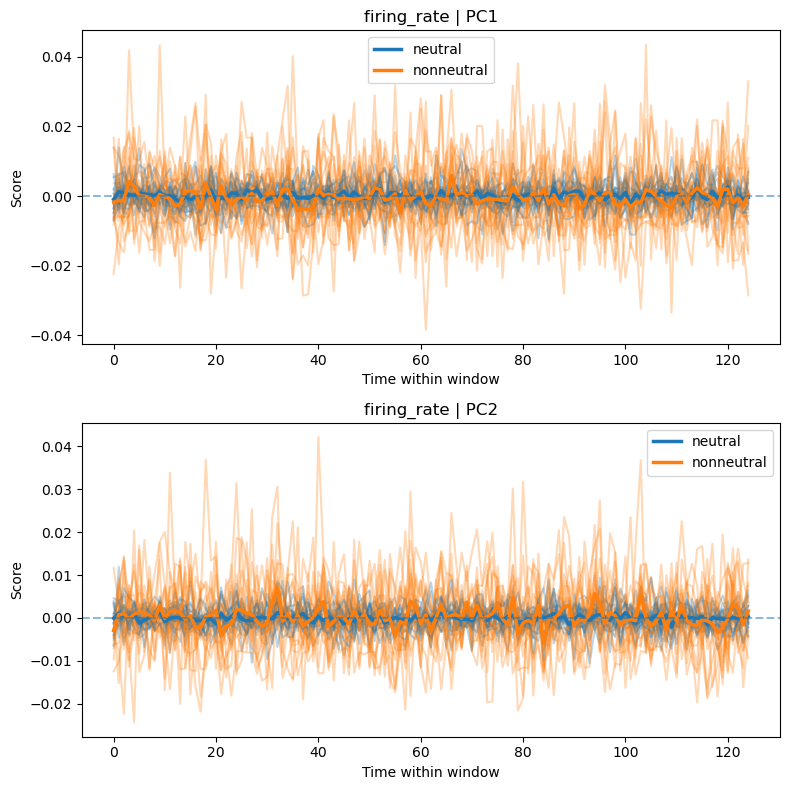

[lfp_macro] [sub=41] split by: emo
[lfp_macro] [sub=41] neutral windows: 1321
[lfp_macro] [sub=41] nonneutral windows: 199
[lfp_macro] [sub=41] shared explained variance ratio: [0.3543594  0.10303569 0.05504808 0.04439301 0.03777948]
[lfp_macro] [sub=42] split by: emo
[lfp_macro] [sub=42] neutral windows: 1321
[lfp_macro] [sub=42] nonneutral windows: 199
[lfp_macro] [sub=42] shared explained variance ratio: [0.31292238 0.10123654 0.07393487 0.04804596 0.04164077]
[lfp_macro] [sub=43] split by: emo
[lfp_macro] [sub=43] neutral windows: 1321
[lfp_macro] [sub=43] nonneutral windows: 199
[lfp_macro] [sub=43] shared explained variance ratio: [0.37749441 0.07495287 0.05045518 0.03704871 0.0343944 ]
[lfp_macro] [sub=44] split by: emo
[lfp_macro] [sub=44] neutral windows: 1321
[lfp_macro] [sub=44] nonneutral windows: 199
[lfp_macro] [sub=44] shared explained variance ratio: [0.292813   0.07765134 0.05696685 0.04074979 0.03643538]
[lfp_macro] [sub=47] split by: emo
[lfp_macro] [sub=47] neutral 

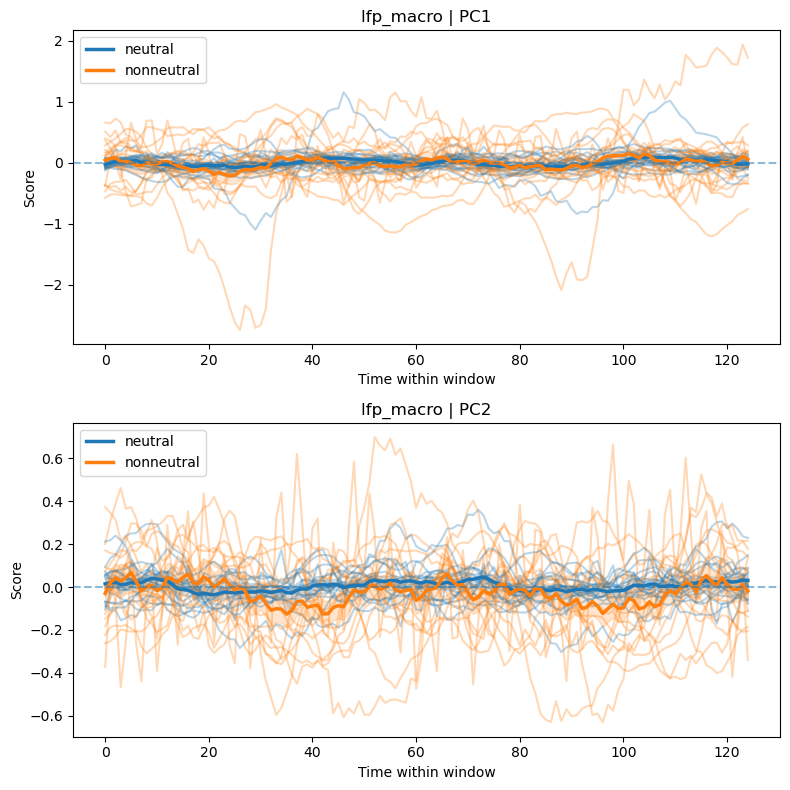

[lfp_micro] [sub=41] split by: emo
[lfp_micro] [sub=41] neutral windows: 1321
[lfp_micro] [sub=41] nonneutral windows: 199
[lfp_micro] [sub=41] shared explained variance ratio: [0.27321553 0.2095517  0.12445735 0.0893801  0.07466349]
[lfp_micro] [sub=42] split by: emo
[lfp_micro] [sub=42] neutral windows: 1321
[lfp_micro] [sub=42] nonneutral windows: 199
[lfp_micro] [sub=42] shared explained variance ratio: [0.13450624 0.09855627 0.0699889  0.06576151 0.05366674]
[lfp_micro] [sub=43] split by: emo
[lfp_micro] [sub=43] neutral windows: 1321
[lfp_micro] [sub=43] nonneutral windows: 199
[lfp_micro] [sub=43] shared explained variance ratio: [0.25019813 0.14676856 0.13556158 0.08040343 0.0675092 ]
[lfp_micro] [sub=44] split by: emo
[lfp_micro] [sub=44] neutral windows: 1321
[lfp_micro] [sub=44] nonneutral windows: 199
[lfp_micro] [sub=44] shared explained variance ratio: [0.21737428 0.13175909 0.08177005 0.07317767 0.06258061]
[lfp_micro] [sub=47] split by: emo
[lfp_micro] [sub=47] neutral 

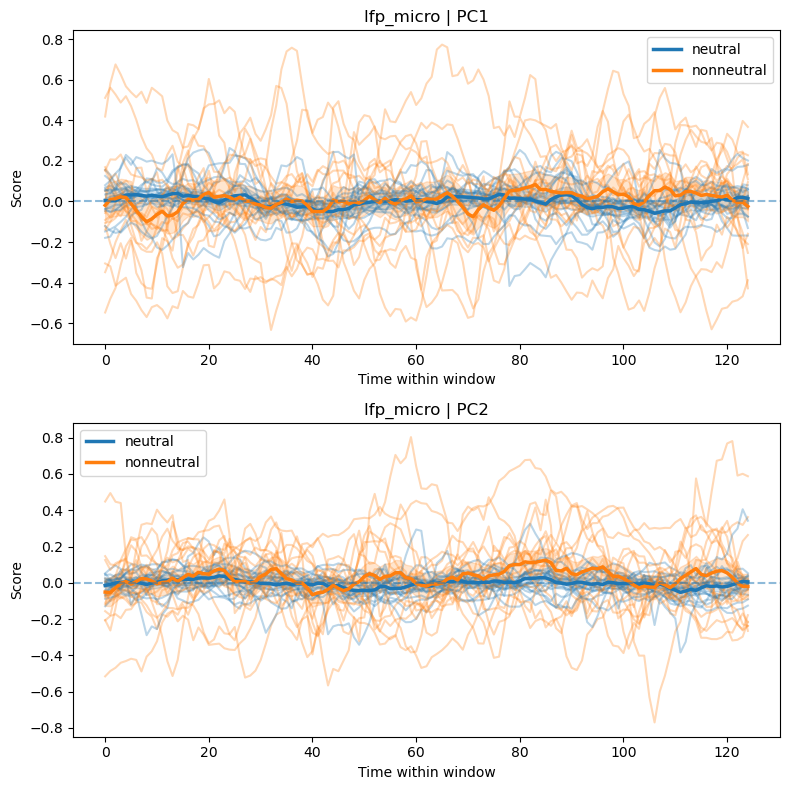

[eye_gaze] [sub=41] split by: emo
[eye_gaze] [sub=41] neutral windows: 1321
[eye_gaze] [sub=41] nonneutral windows: 199
[eye_gaze] [sub=41] shared explained variance ratio: [0.55193049 0.44806951]
[eye_gaze] [sub=42] split by: emo
[eye_gaze] [sub=42] neutral windows: 1321
[eye_gaze] [sub=42] nonneutral windows: 199
[eye_gaze] [sub=42] shared explained variance ratio: [0.59016265 0.40983735]
[eye_gaze] [sub=43] split by: emo
[eye_gaze] [sub=43] neutral windows: 1321
[eye_gaze] [sub=43] nonneutral windows: 199
[eye_gaze] [sub=43] shared explained variance ratio: [0.59231346 0.40768654]
[eye_gaze] [sub=44] split by: emo
[eye_gaze] [sub=44] neutral windows: 1321
[eye_gaze] [sub=44] nonneutral windows: 199
[eye_gaze] [sub=44] shared explained variance ratio: [0.56787151 0.43212849]
[eye_gaze] [sub=47] split by: emo
[eye_gaze] [sub=47] neutral windows: 1321
[eye_gaze] [sub=47] nonneutral windows: 199
[eye_gaze] [sub=47] shared explained variance ratio: [0.55045536 0.44954464]
[eye_gaze] [sub

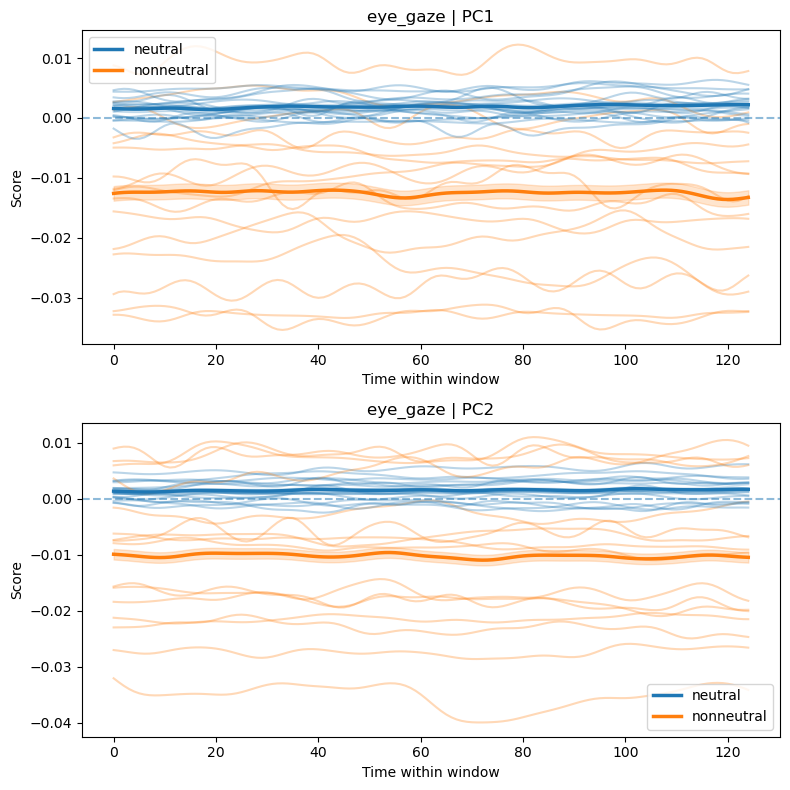

[pupil] [sub=41] split by: emo
[pupil] [sub=41] neutral windows: 1321
[pupil] [sub=41] nonneutral windows: 199
[pupil] [sub=41] shared explained variance ratio: [1.]
[pupil] [sub=42] split by: emo
[pupil] [sub=42] neutral windows: 1321
[pupil] [sub=42] nonneutral windows: 199
[pupil] [sub=42] shared explained variance ratio: [1.]
[pupil] [sub=43] split by: emo
[pupil] [sub=43] neutral windows: 1321
[pupil] [sub=43] nonneutral windows: 199
[pupil] [sub=43] shared explained variance ratio: [1.]
[pupil] [sub=44] split by: emo
[pupil] [sub=44] neutral windows: 1321
[pupil] [sub=44] nonneutral windows: 199
[pupil] [sub=44] shared explained variance ratio: [1.]
[pupil] [sub=47] split by: emo
[pupil] [sub=47] neutral windows: 1321
[pupil] [sub=47] nonneutral windows: 199
[pupil] [sub=47] shared explained variance ratio: [1.]
[pupil] [sub=48] split by: emo
[pupil] [sub=48] neutral windows: 1321
[pupil] [sub=48] nonneutral windows: 199
[pupil] [sub=48] shared explained variance ratio: [1.]
[pup

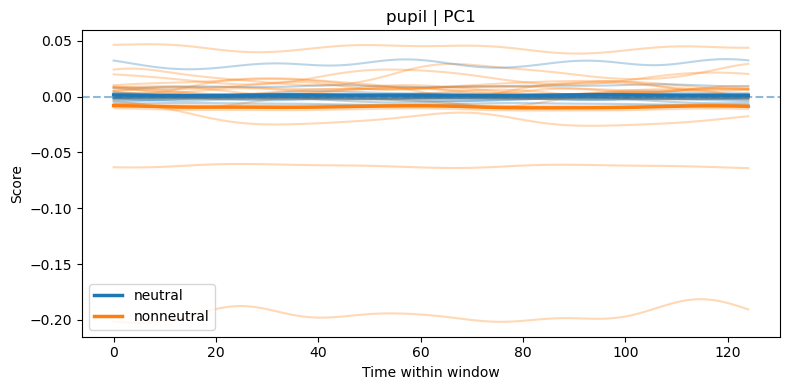

In [21]:
modality_keys = ["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"]
for mod in modality_keys:
    pca_res = decompose.run_grouped_trajectory_pca_on_concat_data(concat_data, modality=mod, n_components=5, split_by_sub=True)

    # decompose.plot_grouped_pca_across_sub(pca_res, pcx=1, pcy=2, alpha=0.3, equal_axis=True)
    # decompose.plot_grouped_pca_across_sub(pca_res, pcx=2, pcy=3, alpha=0.3, equal_axis=True)
    decompose.plot_pc_time_series_across_sub(pca_res, pcs=(1,2))

    # decompose.run_decoding_on_pca_res(pca_res, mode="time_mean")
    # decompose.run_decoding_on_pca_res(pca_res, mode="stats")
    # decompose.run_decoding_on_pca_res(pca_res, mode="channel_mean")

0.0 1.0
[firing_rate] [sub=41] split by: jacky
[firing_rate] [sub=41] no_jacky windows: 366
[firing_rate] [sub=41] jacky_present windows: 1154
[firing_rate] [sub=41] shared explained variance ratio: [0.28705761 0.24912252 0.10068855 0.09981304 0.09305906]
0.0 1.0
[firing_rate] [sub=42] split by: jacky
[firing_rate] [sub=42] no_jacky windows: 366
[firing_rate] [sub=42] jacky_present windows: 1154
[firing_rate] [sub=42] shared explained variance ratio: [0.08646854 0.04894504 0.04371422 0.03971566 0.03916006]
0.0 1.0
[firing_rate] [sub=43] split by: jacky
[firing_rate] [sub=43] no_jacky windows: 366
[firing_rate] [sub=43] jacky_present windows: 1154
[firing_rate] [sub=43] shared explained variance ratio: [0.1208123  0.10991261 0.09081759 0.08859566 0.0598445 ]
0.0 1.0
[firing_rate] [sub=44] split by: jacky
[firing_rate] [sub=44] no_jacky windows: 366
[firing_rate] [sub=44] jacky_present windows: 1154
[firing_rate] [sub=44] shared explained variance ratio: [0.10264635 0.06602153 0.05689517

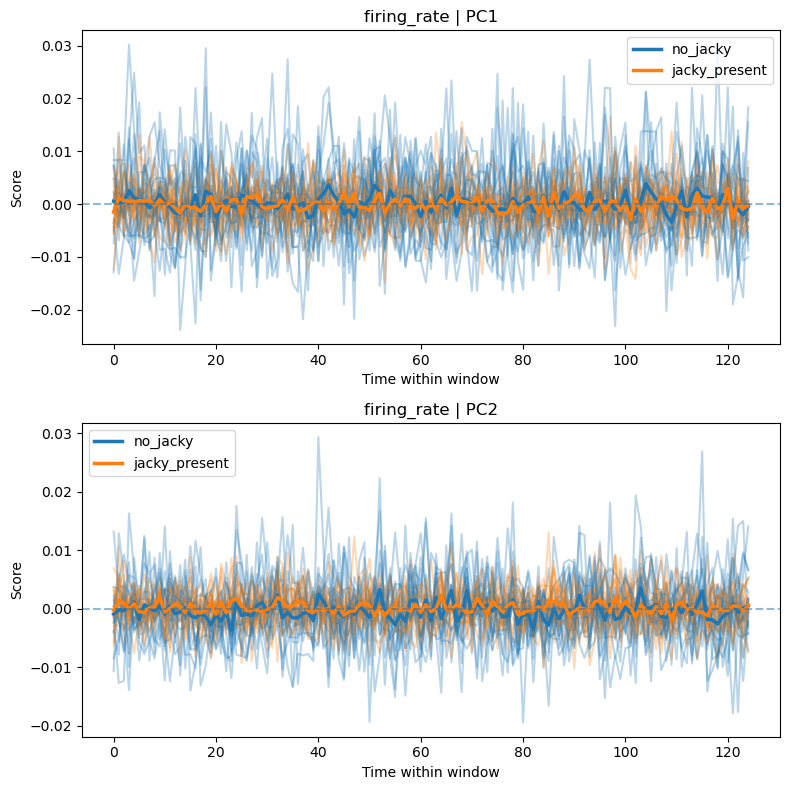

0.0 1.0
[lfp_macro] [sub=41] split by: jacky
[lfp_macro] [sub=41] no_jacky windows: 366
[lfp_macro] [sub=41] jacky_present windows: 1154
[lfp_macro] [sub=41] shared explained variance ratio: [0.3543594  0.10303569 0.05504808 0.04439301 0.03777948]
0.0 1.0
[lfp_macro] [sub=42] split by: jacky
[lfp_macro] [sub=42] no_jacky windows: 366
[lfp_macro] [sub=42] jacky_present windows: 1154
[lfp_macro] [sub=42] shared explained variance ratio: [0.31292238 0.10123654 0.07393487 0.04804596 0.04164077]
0.0 1.0
[lfp_macro] [sub=43] split by: jacky
[lfp_macro] [sub=43] no_jacky windows: 366
[lfp_macro] [sub=43] jacky_present windows: 1154
[lfp_macro] [sub=43] shared explained variance ratio: [0.37749441 0.07495287 0.05045518 0.03704871 0.0343944 ]
0.0 1.0
[lfp_macro] [sub=44] split by: jacky
[lfp_macro] [sub=44] no_jacky windows: 366
[lfp_macro] [sub=44] jacky_present windows: 1154
[lfp_macro] [sub=44] shared explained variance ratio: [0.292813   0.07765134 0.05696685 0.04074979 0.03643538]
0.0 1.0


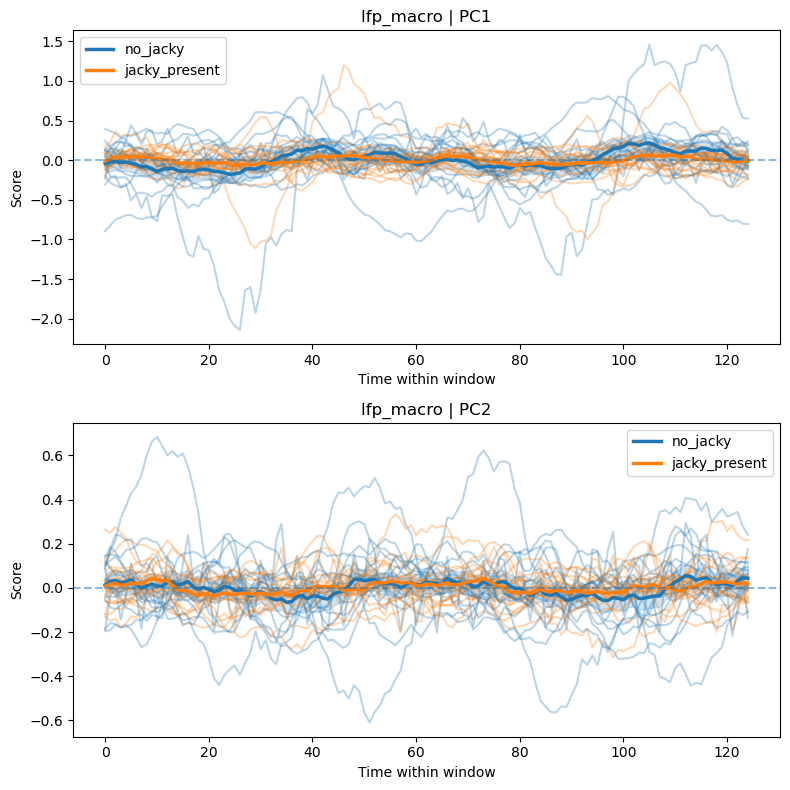

0.0 1.0
[lfp_micro] [sub=41] split by: jacky
[lfp_micro] [sub=41] no_jacky windows: 366
[lfp_micro] [sub=41] jacky_present windows: 1154
[lfp_micro] [sub=41] shared explained variance ratio: [0.27321553 0.2095517  0.12445735 0.0893801  0.07466349]
0.0 1.0
[lfp_micro] [sub=42] split by: jacky
[lfp_micro] [sub=42] no_jacky windows: 366
[lfp_micro] [sub=42] jacky_present windows: 1154
[lfp_micro] [sub=42] shared explained variance ratio: [0.13450624 0.09855627 0.0699889  0.06576151 0.05366674]
0.0 1.0
[lfp_micro] [sub=43] split by: jacky
[lfp_micro] [sub=43] no_jacky windows: 366
[lfp_micro] [sub=43] jacky_present windows: 1154
[lfp_micro] [sub=43] shared explained variance ratio: [0.25019813 0.14676856 0.13556158 0.08040343 0.0675092 ]
0.0 1.0
[lfp_micro] [sub=44] split by: jacky
[lfp_micro] [sub=44] no_jacky windows: 366
[lfp_micro] [sub=44] jacky_present windows: 1154
[lfp_micro] [sub=44] shared explained variance ratio: [0.21737428 0.13175909 0.08177005 0.07317767 0.06258061]
0.0 1.0


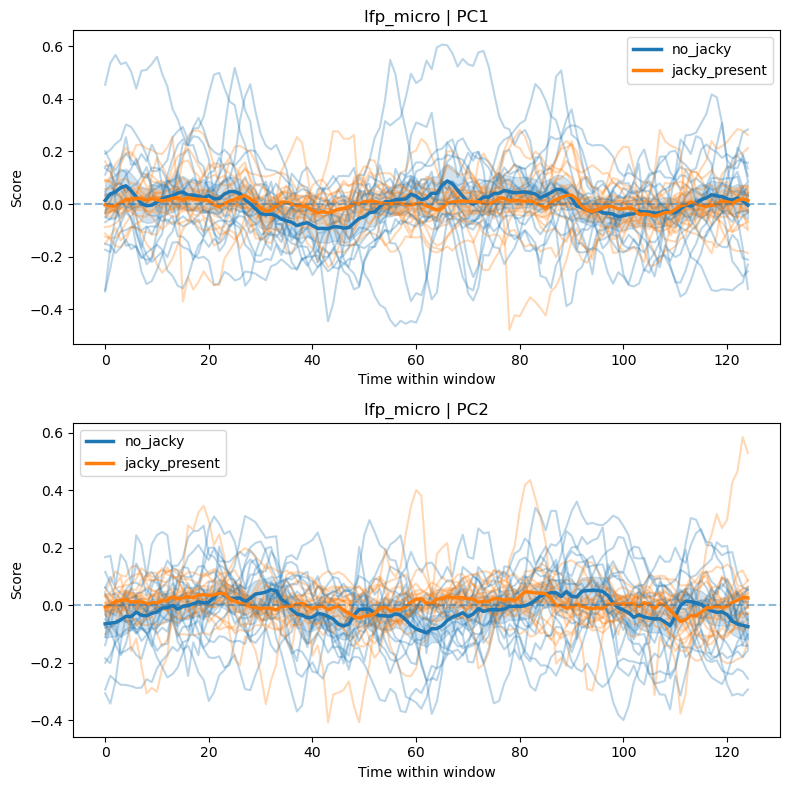

0.0 1.0
[eye_gaze] [sub=41] split by: jacky
[eye_gaze] [sub=41] no_jacky windows: 366
[eye_gaze] [sub=41] jacky_present windows: 1154
[eye_gaze] [sub=41] shared explained variance ratio: [0.55193049 0.44806951]
0.0 1.0
[eye_gaze] [sub=42] split by: jacky
[eye_gaze] [sub=42] no_jacky windows: 366
[eye_gaze] [sub=42] jacky_present windows: 1154
[eye_gaze] [sub=42] shared explained variance ratio: [0.59016265 0.40983735]
0.0 1.0
[eye_gaze] [sub=43] split by: jacky
[eye_gaze] [sub=43] no_jacky windows: 366
[eye_gaze] [sub=43] jacky_present windows: 1154
[eye_gaze] [sub=43] shared explained variance ratio: [0.59231346 0.40768654]
0.0 1.0
[eye_gaze] [sub=44] split by: jacky
[eye_gaze] [sub=44] no_jacky windows: 366
[eye_gaze] [sub=44] jacky_present windows: 1154
[eye_gaze] [sub=44] shared explained variance ratio: [0.56787151 0.43212849]
0.0 1.0
[eye_gaze] [sub=47] split by: jacky
[eye_gaze] [sub=47] no_jacky windows: 366
[eye_gaze] [sub=47] jacky_present windows: 1154
[eye_gaze] [sub=47] sh

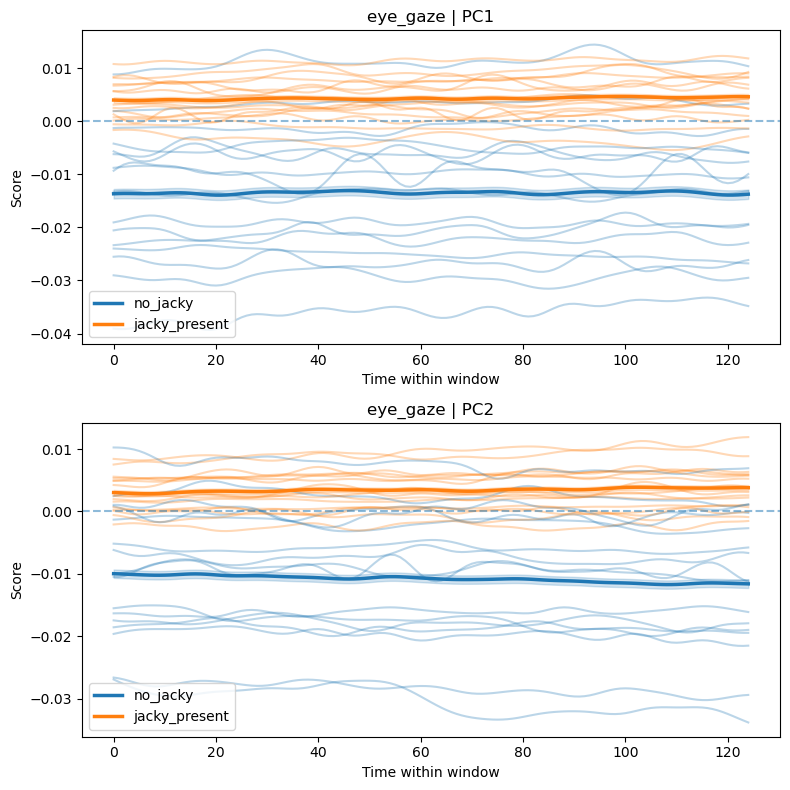

0.0 1.0
[pupil] [sub=41] split by: jacky
[pupil] [sub=41] no_jacky windows: 366
[pupil] [sub=41] jacky_present windows: 1154
[pupil] [sub=41] shared explained variance ratio: [1.]
0.0 1.0
[pupil] [sub=42] split by: jacky
[pupil] [sub=42] no_jacky windows: 366
[pupil] [sub=42] jacky_present windows: 1154
[pupil] [sub=42] shared explained variance ratio: [1.]
0.0 1.0
[pupil] [sub=43] split by: jacky
[pupil] [sub=43] no_jacky windows: 366
[pupil] [sub=43] jacky_present windows: 1154
[pupil] [sub=43] shared explained variance ratio: [1.]
0.0 1.0
[pupil] [sub=44] split by: jacky
[pupil] [sub=44] no_jacky windows: 366
[pupil] [sub=44] jacky_present windows: 1154
[pupil] [sub=44] shared explained variance ratio: [1.]
0.0 1.0
[pupil] [sub=47] split by: jacky
[pupil] [sub=47] no_jacky windows: 366
[pupil] [sub=47] jacky_present windows: 1154
[pupil] [sub=47] shared explained variance ratio: [1.]
0.0 1.0
[pupil] [sub=48] split by: jacky
[pupil] [sub=48] no_jacky windows: 366
[pupil] [sub=48] jac

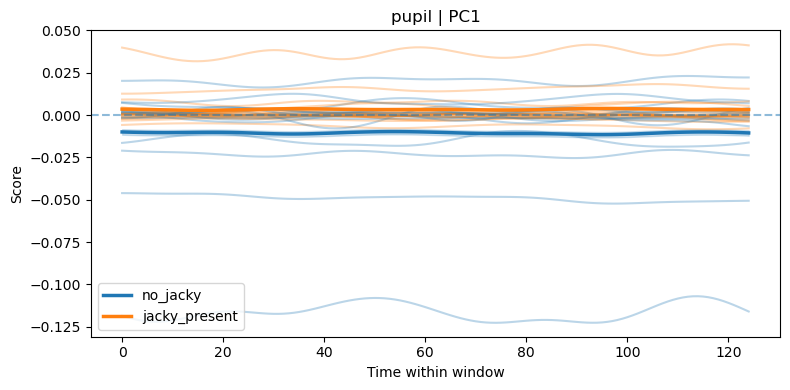

In [22]:
modality_keys = ["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"]
for mod in modality_keys:
    pca_res = decompose.run_grouped_trajectory_pca_on_concat_data(concat_data, spliter="jacky", eps=1.0, modality=mod, n_components=5, split_by_sub=True)

    # decompose.plot_grouped_pca_across_sub(pca_res, pcx=1, pcy=2, alpha=0.3, equal_axis=True)
    # decompose.plot_grouped_pca_across_sub(pca_res, pcx=2, pcy=3, alpha=0.3, equal_axis=True)
    decompose.plot_pc_time_series_across_sub(pca_res, pcs=(1,2))

    # decompose.run_decoding_on_pca_res(pca_res, mode="time_mean")
    # decompose.run_decoding_on_pca_res(pca_res, mode="stats")
    # decompose.run_decoding_on_pca_res(pca_res, mode="bandpower")
    # decompose.run_decoding_on_pca_res(pca_res, mode="channel_mean")

[firing_rate] [sub=41] split by: front_face
[firing_rate] [sub=41] no_front_face windows: 1111
[firing_rate] [sub=41] front_face_present windows: 409
[firing_rate] [sub=41] shared explained variance ratio: [0.28705761 0.24912252 0.10068855 0.09981304 0.09305906]
[firing_rate] [sub=42] split by: front_face
[firing_rate] [sub=42] no_front_face windows: 1111
[firing_rate] [sub=42] front_face_present windows: 409
[firing_rate] [sub=42] shared explained variance ratio: [0.08646854 0.04894504 0.04371422 0.03971566 0.03916006]
[firing_rate] [sub=43] split by: front_face
[firing_rate] [sub=43] no_front_face windows: 1111
[firing_rate] [sub=43] front_face_present windows: 409
[firing_rate] [sub=43] shared explained variance ratio: [0.1208123  0.10991261 0.09081759 0.08859566 0.0598445 ]
[firing_rate] [sub=44] split by: front_face
[firing_rate] [sub=44] no_front_face windows: 1111
[firing_rate] [sub=44] front_face_present windows: 409
[firing_rate] [sub=44] shared explained variance ratio: [0.10

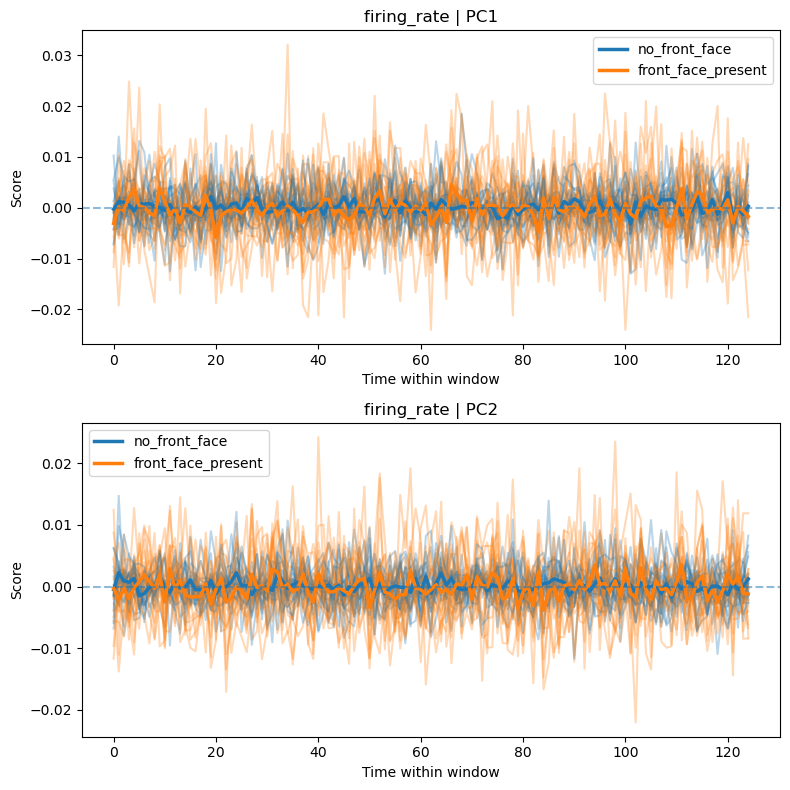

[lfp_macro] [sub=41] split by: front_face
[lfp_macro] [sub=41] no_front_face windows: 1111
[lfp_macro] [sub=41] front_face_present windows: 409
[lfp_macro] [sub=41] shared explained variance ratio: [0.3543594  0.10303569 0.05504808 0.04439301 0.03777948]
[lfp_macro] [sub=42] split by: front_face
[lfp_macro] [sub=42] no_front_face windows: 1111
[lfp_macro] [sub=42] front_face_present windows: 409
[lfp_macro] [sub=42] shared explained variance ratio: [0.31292238 0.10123654 0.07393487 0.04804596 0.04164077]
[lfp_macro] [sub=43] split by: front_face
[lfp_macro] [sub=43] no_front_face windows: 1111
[lfp_macro] [sub=43] front_face_present windows: 409
[lfp_macro] [sub=43] shared explained variance ratio: [0.37749441 0.07495287 0.05045518 0.03704871 0.0343944 ]
[lfp_macro] [sub=44] split by: front_face
[lfp_macro] [sub=44] no_front_face windows: 1111
[lfp_macro] [sub=44] front_face_present windows: 409
[lfp_macro] [sub=44] shared explained variance ratio: [0.292813   0.07765134 0.05696685 0.0

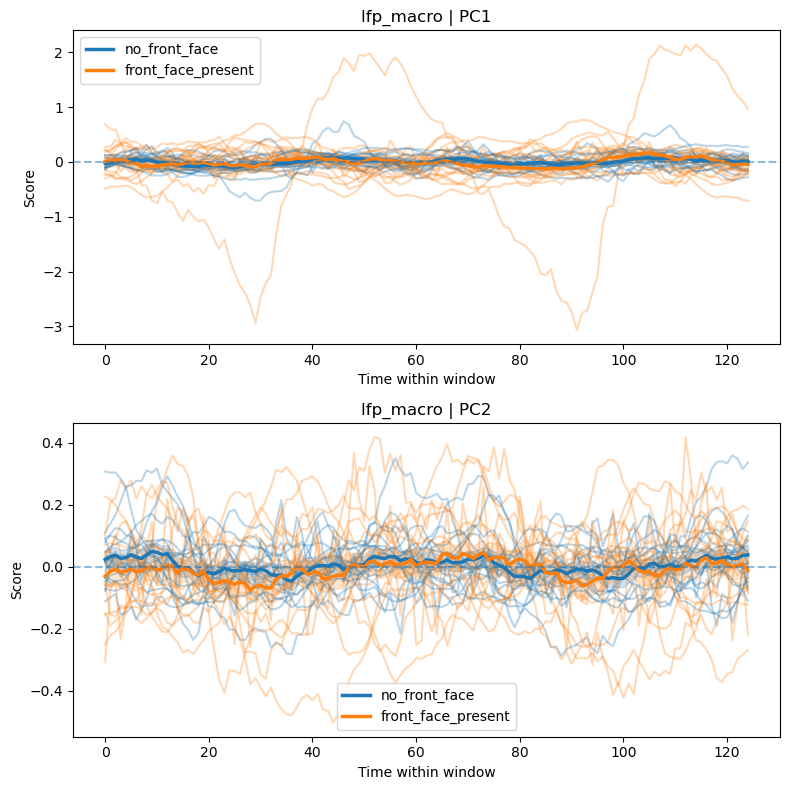

[lfp_micro] [sub=41] split by: front_face
[lfp_micro] [sub=41] no_front_face windows: 1111
[lfp_micro] [sub=41] front_face_present windows: 409
[lfp_micro] [sub=41] shared explained variance ratio: [0.27321553 0.2095517  0.12445735 0.0893801  0.07466349]
[lfp_micro] [sub=42] split by: front_face
[lfp_micro] [sub=42] no_front_face windows: 1111
[lfp_micro] [sub=42] front_face_present windows: 409
[lfp_micro] [sub=42] shared explained variance ratio: [0.13450624 0.09855627 0.0699889  0.06576151 0.05366674]
[lfp_micro] [sub=43] split by: front_face
[lfp_micro] [sub=43] no_front_face windows: 1111
[lfp_micro] [sub=43] front_face_present windows: 409
[lfp_micro] [sub=43] shared explained variance ratio: [0.25019813 0.14676856 0.13556158 0.08040343 0.0675092 ]
[lfp_micro] [sub=44] split by: front_face
[lfp_micro] [sub=44] no_front_face windows: 1111
[lfp_micro] [sub=44] front_face_present windows: 409
[lfp_micro] [sub=44] shared explained variance ratio: [0.21737428 0.13175909 0.08177005 0.0

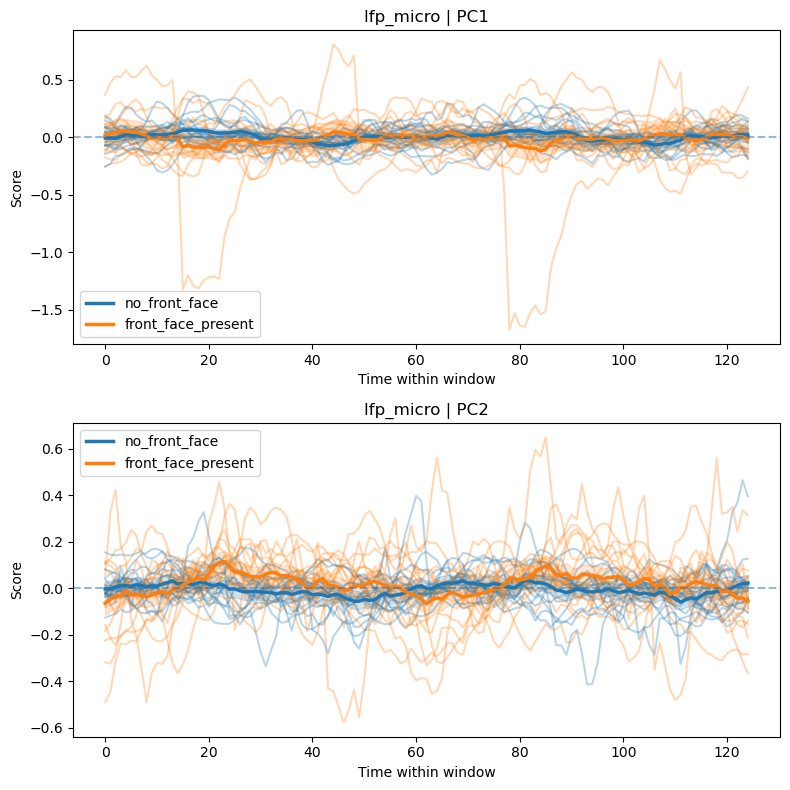

[eye_gaze] [sub=41] split by: front_face
[eye_gaze] [sub=41] no_front_face windows: 1111
[eye_gaze] [sub=41] front_face_present windows: 409
[eye_gaze] [sub=41] shared explained variance ratio: [0.55193049 0.44806951]
[eye_gaze] [sub=42] split by: front_face
[eye_gaze] [sub=42] no_front_face windows: 1111
[eye_gaze] [sub=42] front_face_present windows: 409
[eye_gaze] [sub=42] shared explained variance ratio: [0.59016265 0.40983735]
[eye_gaze] [sub=43] split by: front_face
[eye_gaze] [sub=43] no_front_face windows: 1111
[eye_gaze] [sub=43] front_face_present windows: 409
[eye_gaze] [sub=43] shared explained variance ratio: [0.59231346 0.40768654]
[eye_gaze] [sub=44] split by: front_face
[eye_gaze] [sub=44] no_front_face windows: 1111
[eye_gaze] [sub=44] front_face_present windows: 409
[eye_gaze] [sub=44] shared explained variance ratio: [0.56787151 0.43212849]
[eye_gaze] [sub=47] split by: front_face
[eye_gaze] [sub=47] no_front_face windows: 1111
[eye_gaze] [sub=47] front_face_present 

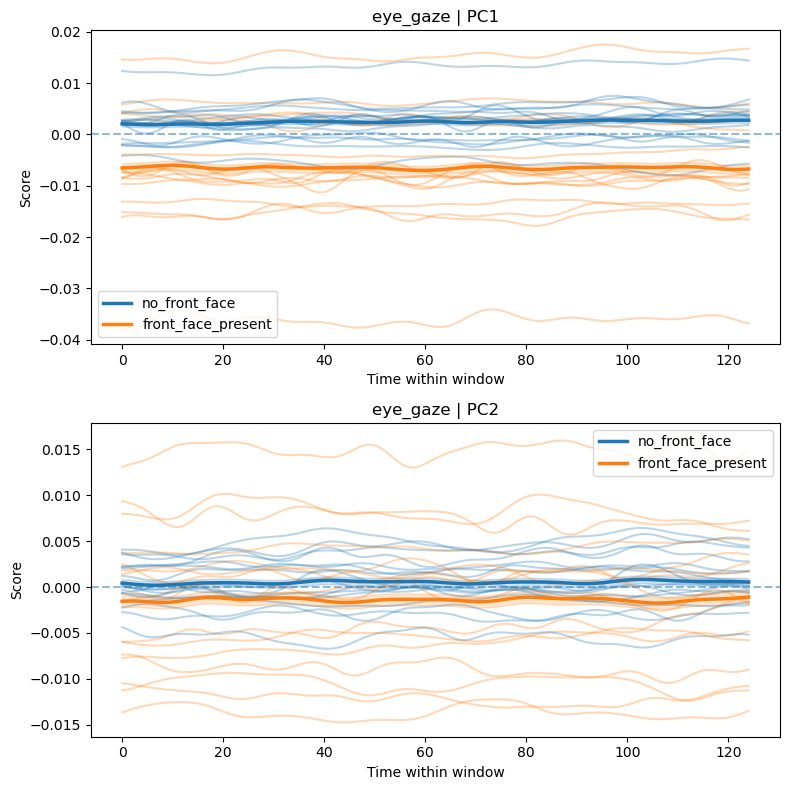

[pupil] [sub=41] split by: front_face
[pupil] [sub=41] no_front_face windows: 1111
[pupil] [sub=41] front_face_present windows: 409
[pupil] [sub=41] shared explained variance ratio: [1.]
[pupil] [sub=42] split by: front_face
[pupil] [sub=42] no_front_face windows: 1111
[pupil] [sub=42] front_face_present windows: 409
[pupil] [sub=42] shared explained variance ratio: [1.]
[pupil] [sub=43] split by: front_face
[pupil] [sub=43] no_front_face windows: 1111
[pupil] [sub=43] front_face_present windows: 409
[pupil] [sub=43] shared explained variance ratio: [1.]
[pupil] [sub=44] split by: front_face
[pupil] [sub=44] no_front_face windows: 1111
[pupil] [sub=44] front_face_present windows: 409
[pupil] [sub=44] shared explained variance ratio: [1.]
[pupil] [sub=47] split by: front_face
[pupil] [sub=47] no_front_face windows: 1111
[pupil] [sub=47] front_face_present windows: 409
[pupil] [sub=47] shared explained variance ratio: [1.]
[pupil] [sub=48] split by: front_face
[pupil] [sub=48] no_front_f

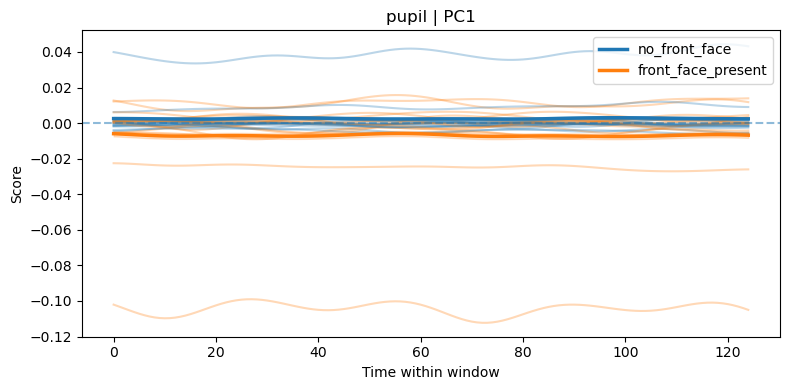

In [23]:
modality_keys = ["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"]
for mod in modality_keys:
    pca_res = decompose.run_grouped_trajectory_pca_on_concat_data(concat_data, spliter="front_face", eps=1.0, modality=mod, n_components=5, split_by_sub=True)

    # decompose.plot_grouped_pca_across_sub(pca_res, pcx=1, pcy=2, alpha=0.3, equal_axis=True)
    # decompose.plot_grouped_pca_across_sub(pca_res, pcx=2, pcy=3, alpha=0.3, equal_axis=True)
    decompose.plot_pc_time_series_across_sub(pca_res, pcs=(1,2))

    # decompose.run_decoding_on_pca_res(pca_res, mode="time_mean")
    # decompose.run_decoding_on_pca_res(pca_res, mode="stats")
    # decompose.run_decoding_on_pca_res(pca_res, mode="channel_mean")

## 4.2 Modality Fusion
### 4.2.1 Feature Summary

[split] sub=41: n_windows=1520
[split] sub=42: n_windows=1520
[split] sub=43: n_windows=1520
[split] sub=44: n_windows=1520
[split] sub=47: n_windows=1520
[split] sub=48: n_windows=1520
[split] sub=49: n_windows=1520
[split] sub=51: n_windows=1520
[split] sub=53: n_windows=1520
[split] sub=54: n_windows=1520
[split] sub=55: n_windows=1520
[split] sub=56: n_windows=1520
[split] sub=57: n_windows=1520
[split] sub=58: n_windows=1520
[split] sub=60: n_windows=1520
[split] sub=62: n_windows=1520
[firing_rate] X.shape=(1520, 77), valid=1520/1520
[lfp_macro] X.shape=(1520, 1056), valid=1520/1520
[lfp_micro] X.shape=(1520, 880), valid=1520/1520
[eye_gaze] X.shape=(1520, 22), valid=1520/1520
[pupil] X.shape=(1520, 11), valid=1520/1520
[subject PCA] sub=41, mod=firing_rate, X_use.shape=(1520, 77), Z.shape=(1520, 10)
[subject PCA] sub=41, mod=lfp_macro, X_use.shape=(1520, 1056), Z.shape=(1520, 10)
[subject PCA] sub=41, mod=lfp_micro, X_use.shape=(1520, 880), Z.shape=(1520, 10)
[subject PCA] sub=4

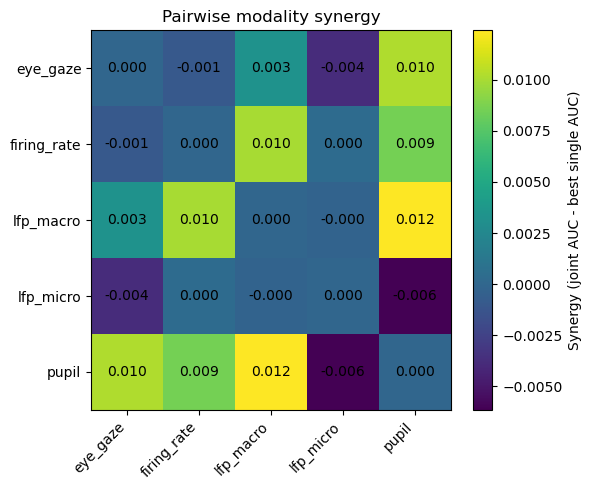

In [24]:
subject_latent_res = new_fusion.build_subjectwise_modality_latents(
    concat_data,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    feature_mode="stats_bandpower",
    pca_dim=10,
    sub_col="sub",
    verbose=True,
)

y_dict = new_fusion.get_label_dict_from_concat_data(
    concat_data,
    y_col="emo_neutral",
    sub_col="sub",
)

stacked_latent = new_fusion.stack_subjectwise_latents(
    subject_latent_res,
    y_dict=y_dict,
    verbose=True,
)

syn_res = new_fusion.compute_pairwise_synergy_matrix_from_latents(
    stacked_latent,
    cv=5,
    verbose=True,
)

new_fusion.plot_synergy_matrix(syn_res)

[stack latent] mod=eye_gaze, shape=(24320, 10), K_common=10
[stack latent] mod=firing_rate, shape=(24320, 10), K_common=10
[stack latent] mod=lfp_macro, shape=(24320, 10), K_common=10
[stack latent] mod=lfp_micro, shape=(24320, 10), K_common=10
[stack latent] mod=pupil, shape=(24320, 10), K_common=10
[single latent] eye_gaze: AUC=0.6075 ± 0.0059
[single latent] firing_rate: AUC=0.5274 ± 0.0107
[single latent] lfp_macro: AUC=0.5255 ± 0.0031
[single latent] lfp_micro: AUC=0.5201 ± 0.0036
[single latent] pupil: AUC=0.5313 ± 0.0052
[pair latent] eye_gaze+firing_rate: AUC=0.6078 ± 0.0030, synergy=0.0003
[pair latent] eye_gaze+lfp_macro: AUC=0.6069 ± 0.0062, synergy=-0.0006
[pair latent] eye_gaze+lfp_micro: AUC=0.6069 ± 0.0059, synergy=-0.0005
[pair latent] eye_gaze+pupil: AUC=0.6091 ± 0.0050, synergy=0.0017
[pair latent] firing_rate+lfp_macro: AUC=0.5381 ± 0.0107, synergy=0.0107
[pair latent] firing_rate+lfp_micro: AUC=0.5324 ± 0.0077, synergy=0.0050
[pair latent] firing_rate+pupil: AUC=0.5

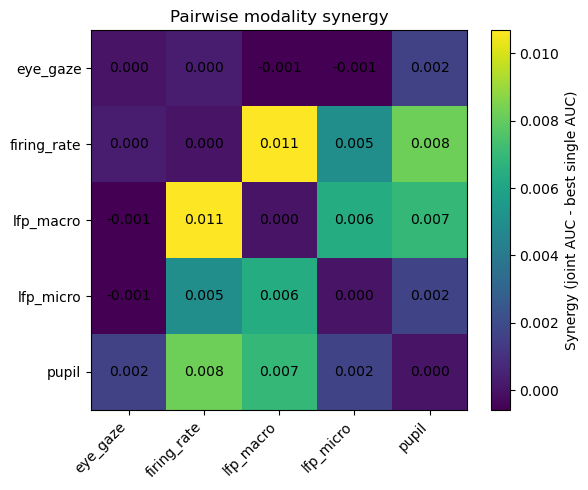

In [25]:
y_dict = new_fusion.get_label_dict_from_concat_data(
    concat_data,
    y_col="jacky_ratio",
    sub_col="sub",
)

stacked_latent = new_fusion.stack_subjectwise_latents(
    subject_latent_res,
    y_dict=y_dict,
    verbose=True,
)

syn_res = new_fusion.compute_pairwise_synergy_matrix_from_latents(
    stacked_latent,
    cv=5,
    verbose=True,
)

new_fusion.plot_synergy_matrix(syn_res)

[stack latent] mod=eye_gaze, shape=(24320, 10), K_common=10
[stack latent] mod=firing_rate, shape=(24320, 10), K_common=10
[stack latent] mod=lfp_macro, shape=(24320, 10), K_common=10
[stack latent] mod=lfp_micro, shape=(24320, 10), K_common=10
[stack latent] mod=pupil, shape=(24320, 10), K_common=10
[single latent] eye_gaze: AUC=0.5583 ± 0.0094
[single latent] firing_rate: AUC=0.5074 ± 0.0030
[single latent] lfp_macro: AUC=0.5124 ± 0.0074
[single latent] lfp_micro: AUC=0.5036 ± 0.0074
[single latent] pupil: AUC=0.5316 ± 0.0066
[pair latent] eye_gaze+firing_rate: AUC=0.5568 ± 0.0084, synergy=-0.0015
[pair latent] eye_gaze+lfp_macro: AUC=0.5580 ± 0.0064, synergy=-0.0003
[pair latent] eye_gaze+lfp_micro: AUC=0.5571 ± 0.0094, synergy=-0.0012
[pair latent] eye_gaze+pupil: AUC=0.5622 ± 0.0124, synergy=0.0039
[pair latent] firing_rate+lfp_macro: AUC=0.5147 ± 0.0066, synergy=0.0023
[pair latent] firing_rate+lfp_micro: AUC=0.5072 ± 0.0056, synergy=-0.0001
[pair latent] firing_rate+pupil: AUC=0

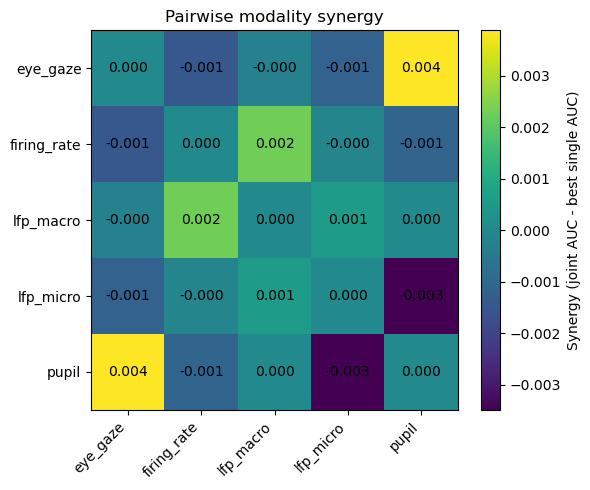

In [26]:
y_dict = new_fusion.get_label_dict_from_concat_data(
    concat_data,
    y_col="front_face_ratio",
    sub_col="sub",
)

stacked_latent = new_fusion.stack_subjectwise_latents(
    subject_latent_res,
    y_dict=y_dict,
    verbose=True,
)

syn_res = new_fusion.compute_pairwise_synergy_matrix_from_latents(
    stacked_latent,
    cv=5,
    verbose=True,
)

new_fusion.plot_synergy_matrix(syn_res)

## AUC Sanity Checking

In [27]:
import numpy as np
import pandas as pd
from itertools import combinations

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score


def _cv_auc(X, y, cv=5, random_state=42):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)

    model = make_pipeline(
        SimpleImputer(strategy="mean"),
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight="balanced")
    )

    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    aucs = cross_val_score(model, X, y, cv=skf, scoring="roc_auc")
    return float(np.mean(aucs)), float(np.std(aucs))


def sanity_check_single_modalities_multisub(
    feat_dict_by_sub,
    valid_mask_dict_by_sub,
    y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    min_windows=10,
    return_per_subject=True,
    verbose=True,
):
    """
    Parameters
    ----------
    feat_dict_by_sub : dict
        {
            sub1: {mod1: [N_sub, F], mod2: ...},
            sub2: ...
        }

    valid_mask_dict_by_sub : dict
        {
            sub1: {mod1: [N_sub] bool, mod2: ...},
            sub2: ...
        }

    y_dict : dict
        {
            sub1: [N_sub],
            sub2: [N_sub],
            ...
        }

    Returns
    -------
    summary_df : DataFrame
        one row per modality, aggregated across subjects

    per_sub_df : DataFrame
        one row per subject x modality
    """
    rng = np.random.default_rng(random_state)

    all_mods = sorted(list(set(
        m for sub in feat_dict_by_sub
        for m in feat_dict_by_sub[sub].keys()
    )))

    rows = []

    for sub in sorted(feat_dict_by_sub.keys()):
        if sub not in valid_mask_dict_by_sub:
            continue
        if sub not in y_dict:
            continue

        y = np.asarray(y_dict[sub])

        for mod in all_mods:
            if mod not in feat_dict_by_sub[sub]:
                continue
            if mod not in valid_mask_dict_by_sub[sub]:
                continue

            X = np.asarray(feat_dict_by_sub[sub][mod], dtype=float)
            mask = np.asarray(valid_mask_dict_by_sub[sub][mod], dtype=bool)

            if len(mask) != len(y):
                raise ValueError(
                    f"sub={sub}, mod={mod}: len(mask)={len(mask)} != len(y)={len(y)}"
                )
            if X.shape[0] != len(y):
                raise ValueError(
                    f"sub={sub}, mod={mod}: X.shape[0]={X.shape[0]} != len(y)={len(y)}"
                )

            mask = mask & np.isfinite(y)
            X_use = X[mask]
            y_use = y[mask]

            n_windows = int(mask.sum())
            n_classes = len(np.unique(y_use))

            if n_windows < max(cv, min_windows):
                if verbose:
                    print(f"[skip] sub={sub}, mod={mod}: too few windows ({n_windows})")
                continue

            if n_classes < 2:
                if verbose:
                    print(f"[skip] sub={sub}, mod={mod}: only one class")
                continue

            try:
                auc_mean, auc_std = _cv_auc(X_use, y_use, cv=cv, random_state=random_state)
            except Exception as e:
                if verbose:
                    print(f"[skip] sub={sub}, mod={mod}: CV failed ({e})")
                continue

            perm_aucs = []
            for _ in range(n_perm):
                y_perm = rng.permutation(y_use)
                try:
                    a, _ = _cv_auc(X_use, y_perm, cv=cv, random_state=random_state)
                    perm_aucs.append(a)
                except Exception:
                    pass

            perm_auc_mean = np.mean(perm_aucs) if len(perm_aucs) > 0 else np.nan
            perm_auc_std = np.std(perm_aucs) if len(perm_aucs) > 0 else np.nan

            rows.append({
                "sub": sub,
                "modality": mod,
                "n_windows": n_windows,
                "n_features": int(X_use.shape[1]),
                "auc_mean": auc_mean,
                "auc_std": auc_std,
                "perm_auc_mean": perm_auc_mean,
                "perm_auc_std": perm_auc_std,
                "delta_over_perm": auc_mean - perm_auc_mean if np.isfinite(perm_auc_mean) else np.nan,
            })

            if verbose:
                print(
                    f"[sub={sub}][{mod}] "
                    f"AUC={auc_mean:.4f}±{auc_std:.4f}, "
                    f"perm={perm_auc_mean:.4f}±{perm_auc_std:.4f}, "
                    f"delta={auc_mean - perm_auc_mean:.4f}"
                )

    per_sub_df = pd.DataFrame(rows)

    if len(per_sub_df) == 0:
        empty_cols = [
            "modality", "n_subjects", "mean_n_windows", "mean_n_features",
            "auc_mean_across_sub", "auc_std_across_sub",
            "perm_auc_mean_across_sub", "perm_auc_std_across_sub",
            "delta_over_perm_across_sub"
        ]
        summary_df = pd.DataFrame(columns=empty_cols)
        return (summary_df, per_sub_df) if return_per_subject else summary_df

    summary_df = (
        per_sub_df
        .groupby("modality", observed=True)
        .agg(
            n_subjects=("sub", "nunique"),
            mean_n_windows=("n_windows", "mean"),
            mean_n_features=("n_features", "mean"),
            auc_mean_across_sub=("auc_mean", "mean"),
            auc_std_across_sub=("auc_mean", "std"),
            perm_auc_mean_across_sub=("perm_auc_mean", "mean"),
            perm_auc_std_across_sub=("perm_auc_mean", "std"),
            delta_over_perm_across_sub=("delta_over_perm", "mean"),
        )
        .reset_index()
        .sort_values("auc_mean_across_sub", ascending=False)
        .reset_index(drop=True)
    )

    return (summary_df, per_sub_df) if return_per_subject else summary_df

def sanity_check_pairwise_synergy_multisub(
    feat_dict_by_sub,
    valid_mask_dict_by_sub,
    y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    min_windows=10,
    return_per_subject=True,
    verbose=True,
):
    """
    Multi-subject pairwise synergy check.

    Parameters
    ----------
    feat_dict_by_sub : dict
        {
            sub1: {mod1: [N_sub, F], mod2: ...},
            sub2: ...
        }

    valid_mask_dict_by_sub : dict
        {
            sub1: {mod1: [N_sub] bool, mod2: ...},
            sub2: ...
        }

    y_dict : dict
        {
            sub1: [N_sub],
            sub2: [N_sub],
            ...
        }

    Returns
    -------
    summary_df : DataFrame
        aggregated over subjects, one row per modality pair

    per_sub_df : DataFrame
        one row per subject x modality pair
    """
    rng = np.random.default_rng(random_state)

    all_mods = sorted(list(set(
        m for sub in feat_dict_by_sub
        for m in feat_dict_by_sub[sub].keys()
    )))

    rows = []

    for sub in sorted(feat_dict_by_sub.keys()):
        if sub not in valid_mask_dict_by_sub:
            continue
        if sub not in y_dict:
            continue

        feat_dict = feat_dict_by_sub[sub]
        valid_mask_dict = valid_mask_dict_by_sub[sub]
        y = np.asarray(y_dict[sub])

        # single-modality AUC
        single_auc = {}

        for mod in all_mods:
            if mod not in feat_dict or mod not in valid_mask_dict:
                single_auc[mod] = np.nan
                continue

            X = np.asarray(feat_dict[mod], dtype=float)
            mask = np.asarray(valid_mask_dict[mod], dtype=bool)

            if len(mask) != len(y):
                raise ValueError(
                    f"sub={sub}, mod={mod}: len(mask)={len(mask)} != len(y)={len(y)}"
                )
            if X.shape[0] != len(y):
                raise ValueError(
                    f"sub={sub}, mod={mod}: X.shape[0]={X.shape[0]} != len(y)={len(y)}"
                )

            mask = mask & np.isfinite(y)
            X_use = X[mask]
            y_use = y[mask]

            if int(mask.sum()) < max(cv, min_windows) or len(np.unique(y_use)) < 2:
                single_auc[mod] = np.nan
                continue

            try:
                single_auc[mod], _ = _cv_auc(X_use, y_use, cv=cv, random_state=random_state)
            except Exception:
                single_auc[mod] = np.nan

        # pairwise
        mods_sub = [m for m in all_mods if m in feat_dict and m in valid_mask_dict]

        for m1, m2 in combinations(mods_sub, 2):
            mask = (
                np.asarray(valid_mask_dict[m1], dtype=bool)
                & np.asarray(valid_mask_dict[m2], dtype=bool)
                & np.isfinite(y)
            )

            n_windows = int(mask.sum())
            if n_windows < max(cv, min_windows):
                if verbose:
                    print(f"[skip] sub={sub}, {m1}+{m2}: too few windows ({n_windows})")
                continue

            y_use = y[mask]
            if len(np.unique(y_use)) < 2:
                if verbose:
                    print(f"[skip] sub={sub}, {m1}+{m2}: only one class")
                continue

            X1 = np.asarray(feat_dict[m1], dtype=float)[mask]
            X2 = np.asarray(feat_dict[m2], dtype=float)[mask]
            X_joint = np.concatenate([X1, X2], axis=1)

            try:
                joint_auc, joint_std = _cv_auc(X_joint, y_use, cv=cv, random_state=random_state)
            except Exception as e:
                if verbose:
                    print(f"[skip] sub={sub}, {m1}+{m2}: CV failed ({e})")
                continue

            best_single = np.nanmax([single_auc.get(m1, np.nan), single_auc.get(m2, np.nan)])
            synergy = joint_auc - best_single if np.isfinite(best_single) else np.nan

            perm_joint_aucs = []
            for _ in range(n_perm):
                y_perm = rng.permutation(y_use)
                try:
                    a, _ = _cv_auc(X_joint, y_perm, cv=cv, random_state=random_state)
                    perm_joint_aucs.append(a)
                except Exception:
                    pass

            perm_joint_mean = np.mean(perm_joint_aucs) if len(perm_joint_aucs) > 0 else np.nan
            perm_joint_std = np.std(perm_joint_aucs) if len(perm_joint_aucs) > 0 else np.nan

            rows.append({
                "sub": sub,
                "mod1": m1,
                "mod2": m2,
                "n_windows": n_windows,
                "n_features_joint": int(X_joint.shape[1]),
                "joint_auc": joint_auc,
                "joint_std": joint_std,
                "best_single_auc": best_single,
                "synergy": synergy,
                "perm_joint_auc_mean": perm_joint_mean,
                "perm_joint_auc_std": perm_joint_std,
                "synergy_vs_perm_joint": joint_auc - perm_joint_mean if np.isfinite(perm_joint_mean) else np.nan,
            })

            if verbose:
                print(
                    f"[sub={sub}][{m1}+{m2}] "
                    f"joint={joint_auc:.4f}, "
                    f"best_single={best_single:.4f}, "
                    f"synergy={synergy:.4f}, "
                    f"vs_perm={joint_auc - perm_joint_mean:.4f}"
                )

    per_sub_df = pd.DataFrame(rows)

    if len(per_sub_df) == 0:
        empty_cols = [
            "mod1", "mod2", "pair", "n_subjects", "mean_n_windows",
            "joint_auc_across_sub", "joint_auc_std_across_sub",
            "best_single_auc_across_sub", "synergy_across_sub",
            "perm_joint_auc_mean_across_sub", "synergy_vs_perm_joint_across_sub"
        ]
        summary_df = pd.DataFrame(columns=empty_cols)
        return (summary_df, per_sub_df) if return_per_subject else summary_df

    per_sub_df["pair"] = per_sub_df["mod1"].astype(str) + " + " + per_sub_df["mod2"].astype(str)

    summary_df = (
        per_sub_df
        .groupby(["mod1", "mod2", "pair"], observed=True)
        .agg(
            n_subjects=("sub", "nunique"),
            mean_n_windows=("n_windows", "mean"),
            joint_auc_across_sub=("joint_auc", "mean"),
            joint_auc_std_across_sub=("joint_auc", "std"),
            best_single_auc_across_sub=("best_single_auc", "mean"),
            synergy_across_sub=("synergy", "mean"),
            synergy_std_across_sub=("synergy", "std"),
            perm_joint_auc_mean_across_sub=("perm_joint_auc_mean", "mean"),
            synergy_vs_perm_joint_across_sub=("synergy_vs_perm_joint", "mean"),
        )
        .reset_index()
        .sort_values("synergy_across_sub", ascending=False)
        .reset_index(drop=True)
    )

    return (summary_df, per_sub_df) if return_per_subject else summary_df

def extract_feat_inputs_from_subject_latent_res(subject_latent_res, use_latent=False):
    """
    use_latent=False -> 用 feat_dict
    use_latent=True  -> 用 latent_dict
    """
    feat_dict_by_sub = {}
    valid_mask_dict_by_sub = {}

    for sub, res in subject_latent_res.items():
        feat_dict_by_sub[sub] = res["latent_dict"] if use_latent else res["feat_dict"]
        valid_mask_dict_by_sub[sub] = res["valid_mask_dict"]

    return feat_dict_by_sub, valid_mask_dict_by_sub

In [28]:
y_dict = new_fusion.get_label_dict_from_concat_data(
    concat_data,
    y_col="jacky_ratio",
    sub_col="sub",
)

feat_dict_by_sub, valid_mask_dict_by_sub = extract_feat_inputs_from_subject_latent_res(
    subject_latent_res,
    use_latent=False,
)

single_summary_df, single_per_sub_df = sanity_check_single_modalities_multisub(
    feat_dict_by_sub=feat_dict_by_sub,
    valid_mask_dict_by_sub=valid_mask_dict_by_sub,
    y_dict=y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    verbose=True,
)
display(single_summary_df)

pair_summary_df, pair_per_sub_df = sanity_check_pairwise_synergy_multisub(
    feat_dict_by_sub=feat_dict_by_sub,
    valid_mask_dict_by_sub=valid_mask_dict_by_sub,
    y_dict=y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    verbose=True,
)

display(pair_summary_df)

[sub=41][eye_gaze] AUC=0.6669±0.0373, perm=0.5032±0.0258, delta=0.1637
[sub=41][firing_rate] AUC=0.5307±0.0282, perm=0.4946±0.0222, delta=0.0360
[sub=41][lfp_macro] AUC=0.6125±0.0334, perm=0.4984±0.0230, delta=0.1141
[sub=41][lfp_micro] AUC=0.6588±0.0286, perm=0.4971±0.0262, delta=0.1617
[sub=41][pupil] AUC=0.5383±0.0328, perm=0.5014±0.0187, delta=0.0368
[sub=42][eye_gaze] AUC=0.6788±0.0490, perm=0.4873±0.0241, delta=0.1915
[sub=42][firing_rate] AUC=0.6265±0.0401, perm=0.4975±0.0191, delta=0.1290
[sub=42][lfp_macro] AUC=0.5794±0.0314, perm=0.4946±0.0248, delta=0.0848
[sub=42][lfp_micro] AUC=0.6654±0.0275, perm=0.5047±0.0225, delta=0.1607
[sub=42][pupil] AUC=0.5298±0.0233, perm=0.4906±0.0262, delta=0.0391
[sub=43][eye_gaze] AUC=0.7038±0.0257, perm=0.5066±0.0208, delta=0.1972
[sub=43][firing_rate] AUC=0.6775±0.0264, perm=0.4994±0.0232, delta=0.1781
[sub=43][lfp_macro] AUC=0.6698±0.0268, perm=0.4995±0.0196, delta=0.1703
[sub=43][lfp_micro] AUC=0.6319±0.0255, perm=0.4931±0.0290, delta=0.13

,modality,n_subjects,mean_n_windows,mean_n_features,auc_mean_across_sub,auc_std_across_sub,perm_auc_mean_across_sub,perm_auc_std_across_sub,delta_over_perm_across_sub
0,eye_gaze,16,1520.0,22.0000,0.671127,0.038493,0.501911,0.005358,0.169216
1,lfp_macro,16,1520.0,1040.8750,0.636595,0.051619,0.497933,0.005233,0.138662
2,firing_rate,16,1520.0,574.0625,0.630099,0.056728,0.499285,0.005515,0.130814
3,lfp_micro,16,1520.0,841.5000,0.620785,0.044101,0.499479,0.005375,0.121307
4,pupil,16,1520.0,11.0000,0.571199,0.042632,0.496156,0.004856,0.075044


[sub=41][eye_gaze+firing_rate] joint=0.6437, best_single=0.6669, synergy=-0.0233, vs_perm=0.1389
[sub=41][eye_gaze+lfp_macro] joint=0.6440, best_single=0.6669, synergy=-0.0229, vs_perm=0.1433
[sub=41][eye_gaze+lfp_micro] joint=0.6858, best_single=0.6669, synergy=0.0189, vs_perm=0.2004
[sub=41][eye_gaze+pupil] joint=0.6601, best_single=0.6669, synergy=-0.0068, vs_perm=0.1775
[sub=41][firing_rate+lfp_macro] joint=0.6266, best_single=0.6125, synergy=0.0142, vs_perm=0.1206
[sub=41][firing_rate+lfp_micro] joint=0.6463, best_single=0.6588, synergy=-0.0125, vs_perm=0.1489
[sub=41][firing_rate+pupil] joint=0.5385, best_single=0.5383, synergy=0.0002, vs_perm=0.0526
[sub=41][lfp_macro+lfp_micro] joint=0.6409, best_single=0.6588, synergy=-0.0179, vs_perm=0.1438
[sub=41][lfp_macro+pupil] joint=0.6233, best_single=0.6125, synergy=0.0108, vs_perm=0.1204
[sub=41][lfp_micro+pupil] joint=0.6627, best_single=0.6588, synergy=0.0038, vs_perm=0.1557
[sub=42][eye_gaze+firing_rate] joint=0.6644, best_single=

,mod1,mod2,pair,n_subjects,mean_n_windows,joint_auc_across_sub,joint_auc_std_across_sub,best_single_auc_across_sub,synergy_across_sub,synergy_std_across_sub,perm_joint_auc_mean_across_sub,synergy_vs_perm_joint_across_sub
0,firing_rate,lfp_macro,firing_rate + lfp_macro,16,1520.0,0.685418,0.056476,0.659545,0.025873,0.022100,0.496855,0.188563
1,lfp_macro,lfp_micro,lfp_macro + lfp_micro,16,1520.0,0.673531,0.047511,0.653453,0.020078,0.023246,0.498645,0.174886
2,firing_rate,lfp_micro,firing_rate + lfp_micro,16,1520.0,0.670573,0.047963,0.655609,0.014964,0.017023,0.499105,0.171468
3,eye_gaze,pupil,eye_gaze + pupil,16,1520.0,0.676486,0.038994,0.671585,0.004902,0.011274,0.497217,0.179270
4,firing_rate,pupil,firing_rate + pupil,16,1520.0,0.640184,0.057254,0.636301,0.003883,0.013507,0.498328,0.141856
5,lfp_macro,pupil,lfp_macro + pupil,16,1520.0,0.643852,0.048333,0.648151,-0.004299,0.023318,0.500682,0.143169
6,lfp_micro,pupil,lfp_micro + pupil,16,1520.0,0.627079,0.042011,0.632113,-0.005034,0.018382,0.501336,0.125743
7,eye_gaze,firing_rate,eye_gaze + firing_rate,16,1520.0,0.673512,0.047416,0.679436,-0.005924,0.030376,0.499204,0.174308
8,eye_gaze,lfp_macro,eye_gaze + lfp_macro,16,1520.0,0.666492,0.048185,0.678443,-0.011951,0.040943,0.499348,0.167143
9,eye_gaze,lfp_micro,eye_gaze + lfp_micro,16,1520.0,0.653057,0.040806,0.674539,-0.021482,0.043695,0.499311,0.153746


In [29]:
y_dict = new_fusion.get_label_dict_from_concat_data(
    concat_data,
    y_col="front_face_ratio",
    sub_col="sub",
)

feat_dict_by_sub, valid_mask_dict_by_sub = extract_feat_inputs_from_subject_latent_res(
    subject_latent_res,
    use_latent=False,
)

single_summary_df, single_per_sub_df = sanity_check_single_modalities_multisub(
    feat_dict_by_sub=feat_dict_by_sub,
    valid_mask_dict_by_sub=valid_mask_dict_by_sub,
    y_dict=y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    verbose=True,
)
display(single_summary_df)

pair_summary_df, pair_per_sub_df = sanity_check_pairwise_synergy_multisub(
    feat_dict_by_sub=feat_dict_by_sub,
    valid_mask_dict_by_sub=valid_mask_dict_by_sub,
    y_dict=y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    verbose=True,
)

display(pair_summary_df)

[sub=41][eye_gaze] AUC=0.5937±0.0382, perm=0.5040±0.0184, delta=0.0896
[sub=41][firing_rate] AUC=0.5139±0.0300, perm=0.4960±0.0194, delta=0.0180
[sub=41][lfp_macro] AUC=0.5890±0.0474, perm=0.4982±0.0175, delta=0.0908
[sub=41][lfp_micro] AUC=0.6078±0.0216, perm=0.4990±0.0161, delta=0.1088
[sub=41][pupil] AUC=0.5309±0.0237, perm=0.5047±0.0194, delta=0.0261
[sub=42][eye_gaze] AUC=0.6147±0.0398, perm=0.4922±0.0199, delta=0.1226
[sub=42][firing_rate] AUC=0.6059±0.0159, perm=0.5072±0.0227, delta=0.0988
[sub=42][lfp_macro] AUC=0.5704±0.0188, perm=0.4908±0.0219, delta=0.0795
[sub=42][lfp_micro] AUC=0.6094±0.0385, perm=0.4938±0.0182, delta=0.1156
[sub=42][pupil] AUC=0.5427±0.0397, perm=0.4987±0.0168, delta=0.0440
[sub=43][eye_gaze] AUC=0.6163±0.0397, perm=0.4953±0.0189, delta=0.1210
[sub=43][firing_rate] AUC=0.6110±0.0221, perm=0.4951±0.0125, delta=0.1160
[sub=43][lfp_macro] AUC=0.5753±0.0276, perm=0.5092±0.0187, delta=0.0660
[sub=43][lfp_micro] AUC=0.5661±0.0235, perm=0.5050±0.0168, delta=0.06

,modality,n_subjects,mean_n_windows,mean_n_features,auc_mean_across_sub,auc_std_across_sub,perm_auc_mean_across_sub,perm_auc_std_across_sub,delta_over_perm_across_sub
0,eye_gaze,16,1520.0,22.0000,0.612220,0.027071,0.499940,0.005985,0.112281
1,firing_rate,16,1520.0,574.0625,0.591660,0.041010,0.498094,0.005919,0.093565
2,lfp_micro,16,1520.0,841.5000,0.585915,0.035687,0.499809,0.004133,0.086106
3,lfp_macro,16,1520.0,1040.8750,0.583607,0.019130,0.500088,0.004649,0.083520
4,pupil,16,1520.0,11.0000,0.561345,0.043245,0.501378,0.003928,0.059968


[sub=41][eye_gaze+firing_rate] joint=0.5768, best_single=0.5937, synergy=-0.0169, vs_perm=0.0749
[sub=41][eye_gaze+lfp_macro] joint=0.6105, best_single=0.5937, synergy=0.0168, vs_perm=0.1102
[sub=41][eye_gaze+lfp_micro] joint=0.6238, best_single=0.6078, synergy=0.0161, vs_perm=0.1298
[sub=41][eye_gaze+pupil] joint=0.5908, best_single=0.5937, synergy=-0.0028, vs_perm=0.0869
[sub=41][firing_rate+lfp_macro] joint=0.5949, best_single=0.5890, synergy=0.0059, vs_perm=0.0912
[sub=41][firing_rate+lfp_micro] joint=0.6052, best_single=0.6078, synergy=-0.0026, vs_perm=0.1000
[sub=41][firing_rate+pupil] joint=0.5217, best_single=0.5309, synergy=-0.0091, vs_perm=0.0183
[sub=41][lfp_macro+lfp_micro] joint=0.5998, best_single=0.6078, synergy=-0.0080, vs_perm=0.1010
[sub=41][lfp_macro+pupil] joint=0.5865, best_single=0.5890, synergy=-0.0025, vs_perm=0.0815
[sub=41][lfp_micro+pupil] joint=0.6049, best_single=0.6078, synergy=-0.0029, vs_perm=0.1004
[sub=42][eye_gaze+firing_rate] joint=0.6415, best_singl

,mod1,mod2,pair,n_subjects,mean_n_windows,joint_auc_across_sub,joint_auc_std_across_sub,best_single_auc_across_sub,synergy_across_sub,synergy_std_across_sub,perm_joint_auc_mean_across_sub,synergy_vs_perm_joint_across_sub
0,lfp_macro,lfp_micro,lfp_macro + lfp_micro,16,1520.0,0.614267,0.033351,0.598492,0.015775,0.020210,0.498921,0.115345
1,firing_rate,lfp_macro,firing_rate + lfp_macro,16,1520.0,0.619035,0.032068,0.604314,0.014721,0.018802,0.501093,0.117942
2,eye_gaze,pupil,eye_gaze + pupil,16,1520.0,0.627421,0.041048,0.614074,0.013347,0.019707,0.502532,0.124889
3,firing_rate,lfp_micro,firing_rate + lfp_micro,16,1520.0,0.618671,0.038167,0.607458,0.011212,0.019311,0.500262,0.118409
4,eye_gaze,firing_rate,eye_gaze + firing_rate,16,1520.0,0.624968,0.034508,0.622329,0.002638,0.020417,0.499996,0.124972
5,firing_rate,pupil,firing_rate + pupil,16,1520.0,0.599646,0.039538,0.603369,-0.003723,0.016924,0.499105,0.100541
6,lfp_micro,pupil,lfp_micro + pupil,16,1520.0,0.591210,0.034311,0.598366,-0.007156,0.016644,0.498761,0.092449
7,lfp_macro,pupil,lfp_macro + pupil,16,1520.0,0.589735,0.018547,0.597182,-0.007447,0.024043,0.500524,0.089211
8,eye_gaze,lfp_macro,eye_gaze + lfp_macro,16,1520.0,0.604732,0.019823,0.614681,-0.009949,0.020087,0.500452,0.104280
9,eye_gaze,lfp_micro,eye_gaze + lfp_micro,16,1520.0,0.607940,0.035679,0.618437,-0.010497,0.021769,0.498901,0.109039


In [30]:
y_dict = new_fusion.get_label_dict_from_concat_data(
    concat_data,
    y_col="emo_neutral",
    sub_col="sub",
)

feat_dict_by_sub, valid_mask_dict_by_sub = extract_feat_inputs_from_subject_latent_res(
    subject_latent_res,
    use_latent=False,
)

single_summary_df, single_per_sub_df = sanity_check_single_modalities_multisub(
    feat_dict_by_sub=feat_dict_by_sub,
    valid_mask_dict_by_sub=valid_mask_dict_by_sub,
    y_dict=y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    verbose=True,
)
display(single_summary_df)

pair_summary_df, pair_per_sub_df = sanity_check_pairwise_synergy_multisub(
    feat_dict_by_sub=feat_dict_by_sub,
    valid_mask_dict_by_sub=valid_mask_dict_by_sub,
    y_dict=y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    verbose=True,
)

display(pair_summary_df)

[sub=41][eye_gaze] AUC=0.6426±0.0226, perm=0.4969±0.0270, delta=0.1457
[sub=41][firing_rate] AUC=0.5255±0.0424, perm=0.5050±0.0305, delta=0.0205
[sub=41][lfp_macro] AUC=0.7014±0.0458, perm=0.4923±0.0327, delta=0.2092
[sub=41][lfp_micro] AUC=0.7268±0.0532, perm=0.5012±0.0283, delta=0.2256
[sub=41][pupil] AUC=0.5536±0.0294, perm=0.5128±0.0328, delta=0.0408
[sub=42][eye_gaze] AUC=0.6657±0.0369, perm=0.4922±0.0302, delta=0.1734
[sub=42][firing_rate] AUC=0.6360±0.0239, perm=0.4975±0.0325, delta=0.1385
[sub=42][lfp_macro] AUC=0.6549±0.0443, perm=0.5013±0.0341, delta=0.1536
[sub=42][lfp_micro] AUC=0.8004±0.0300, perm=0.4959±0.0314, delta=0.3045
[sub=42][pupil] AUC=0.5192±0.0301, perm=0.5050±0.0317, delta=0.0143
[sub=43][eye_gaze] AUC=0.6564±0.0240, perm=0.4984±0.0306, delta=0.1580
[sub=43][firing_rate] AUC=0.7167±0.0225, perm=0.4970±0.0300, delta=0.2196
[sub=43][lfp_macro] AUC=0.7630±0.0444, perm=0.5000±0.0277, delta=0.2630
[sub=43][lfp_micro] AUC=0.6883±0.0395, perm=0.5018±0.0387, delta=0.18

,modality,n_subjects,mean_n_windows,mean_n_features,auc_mean_across_sub,auc_std_across_sub,perm_auc_mean_across_sub,perm_auc_std_across_sub,delta_over_perm_across_sub
0,lfp_macro,16,1520.0,1040.8750,0.705210,0.051554,0.498944,0.007062,0.206266
1,lfp_micro,16,1520.0,841.5000,0.695462,0.049704,0.502354,0.005497,0.193108
2,firing_rate,16,1520.0,574.0625,0.683345,0.083519,0.499258,0.008760,0.184087
3,eye_gaze,16,1520.0,22.0000,0.659038,0.040976,0.499433,0.006338,0.159605
4,pupil,16,1520.0,11.0000,0.607548,0.081508,0.497842,0.006772,0.109706


[sub=41][eye_gaze+firing_rate] joint=0.6124, best_single=0.6426, synergy=-0.0302, vs_perm=0.1163
[sub=41][eye_gaze+lfp_macro] joint=0.7072, best_single=0.7014, synergy=0.0058, vs_perm=0.2034
[sub=41][eye_gaze+lfp_micro] joint=0.7513, best_single=0.7268, synergy=0.0245, vs_perm=0.2641
[sub=41][eye_gaze+pupil] joint=0.6510, best_single=0.6426, synergy=0.0083, vs_perm=0.1540
[sub=41][firing_rate+lfp_macro] joint=0.7088, best_single=0.7014, synergy=0.0073, vs_perm=0.2091
[sub=41][firing_rate+lfp_micro] joint=0.7297, best_single=0.7268, synergy=0.0029, vs_perm=0.2381
[sub=41][firing_rate+pupil] joint=0.5497, best_single=0.5536, synergy=-0.0039, vs_perm=0.0428
[sub=41][lfp_macro+lfp_micro] joint=0.7436, best_single=0.7268, synergy=0.0168, vs_perm=0.2290
[sub=41][lfp_macro+pupil] joint=0.7135, best_single=0.7014, synergy=0.0121, vs_perm=0.2152
[sub=41][lfp_micro+pupil] joint=0.7392, best_single=0.7268, synergy=0.0123, vs_perm=0.2359
[sub=42][eye_gaze+firing_rate] joint=0.7062, best_single=0.6

,mod1,mod2,pair,n_subjects,mean_n_windows,joint_auc_across_sub,joint_auc_std_across_sub,best_single_auc_across_sub,synergy_across_sub,synergy_std_across_sub,perm_joint_auc_mean_across_sub,synergy_vs_perm_joint_across_sub
0,firing_rate,lfp_macro,firing_rate + lfp_macro,16,1520.0,0.769540,0.053410,0.738368,0.031172,0.024462,0.501390,0.268151
1,lfp_macro,lfp_micro,lfp_macro + lfp_micro,16,1520.0,0.755262,0.050040,0.724728,0.030535,0.020094,0.501039,0.254224
2,firing_rate,lfp_micro,firing_rate + lfp_micro,16,1520.0,0.755747,0.051355,0.737160,0.018588,0.020592,0.498773,0.256974
3,eye_gaze,pupil,eye_gaze + pupil,16,1520.0,0.683602,0.053317,0.673521,0.010081,0.019210,0.500563,0.183039
4,eye_gaze,firing_rate,eye_gaze + firing_rate,16,1520.0,0.720143,0.065689,0.710347,0.009796,0.022782,0.500070,0.220073
5,eye_gaze,lfp_micro,eye_gaze + lfp_micro,16,1520.0,0.717261,0.043348,0.710621,0.006640,0.024971,0.497624,0.219637
6,eye_gaze,lfp_macro,eye_gaze + lfp_macro,16,1520.0,0.724036,0.041865,0.717779,0.006257,0.015974,0.502937,0.221099
7,lfp_micro,pupil,lfp_micro + pupil,16,1520.0,0.710220,0.049333,0.705657,0.004563,0.020317,0.500164,0.210056
8,lfp_macro,pupil,lfp_macro + pupil,16,1520.0,0.718203,0.051950,0.715953,0.002249,0.018509,0.500662,0.217540
9,firing_rate,pupil,firing_rate + pupil,16,1520.0,0.701763,0.074237,0.705502,-0.003739,0.025806,0.500644,0.201118


## CCA

[subject CCA] sub=41, firing_rate vs lfp_macro: 0.169, 0.125, 0.121
[subject CCA] sub=42, firing_rate vs lfp_macro: 0.321, 0.204, 0.165
[subject CCA] sub=43, firing_rate vs lfp_macro: 0.419, 0.225, 0.176
[subject CCA] sub=44, firing_rate vs lfp_macro: 0.263, 0.195, 0.174
[subject CCA] sub=47, firing_rate vs lfp_macro: 0.313, 0.259, 0.159
[subject CCA] sub=48, firing_rate vs lfp_macro: 0.379, 0.300, 0.274
[subject CCA] sub=49, firing_rate vs lfp_macro: 0.265, 0.188, 0.140
[subject CCA] sub=51, firing_rate vs lfp_macro: 0.210, 0.148, 0.135
[subject CCA] sub=53, firing_rate vs lfp_macro: 0.282, 0.224, 0.199
[subject CCA] sub=54, firing_rate vs lfp_macro: 0.615, 0.403, 0.282
[subject CCA] sub=55, firing_rate vs lfp_macro: 0.335, 0.229, 0.185
[subject CCA] sub=56, firing_rate vs lfp_macro: 0.349, 0.275, 0.198
[subject CCA] sub=57, firing_rate vs lfp_macro: 0.303, 0.189, 0.138
[subject CCA] sub=58, firing_rate vs lfp_macro: 0.360, 0.265, 0.171
[subject CCA] sub=60, firing_rate vs lfp_macro: 

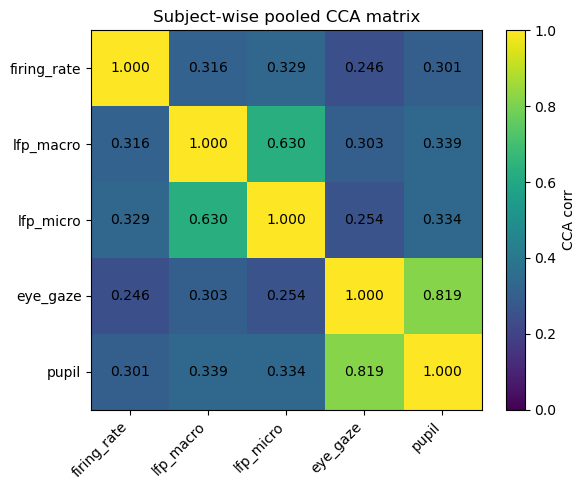

In [31]:
cca_res = new_fusion.compute_pairwise_cca_subjectwise(
    subject_latent_res,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    n_components=3,
    min_windows=20,
    verbose=True,
)

new_fusion.plot_cca_corr_heatmap_from_matrix(
    cca_res,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    mode="first",
    title="Subject-wise pooled CCA matrix",
)

# new_fusion.plot_cca_pair_scatter(
#     cca_res,
#     "firing_rate",
#     "eye_gaze",
#     comp=1,
# )

[time-PCA] sub=41, modality=firing_rate, X=(1520, 125, 7), Z=(1520, 125, 5)
[time-PCA] sub=42, modality=firing_rate, X=(1520, 125, 50), Z=(1520, 125, 5)
[time-PCA] sub=43, modality=firing_rate, X=(1520, 125, 32), Z=(1520, 125, 5)
[time-PCA] sub=44, modality=firing_rate, X=(1520, 125, 49), Z=(1520, 125, 5)
[time-PCA] sub=47, modality=firing_rate, X=(1520, 125, 75), Z=(1520, 125, 5)
[time-PCA] sub=48, modality=firing_rate, X=(1520, 125, 143), Z=(1520, 125, 5)
[time-PCA] sub=49, modality=firing_rate, X=(1520, 125, 12), Z=(1520, 125, 5)
[time-PCA] sub=51, modality=firing_rate, X=(1520, 125, 30), Z=(1520, 125, 5)
[time-PCA] sub=53, modality=firing_rate, X=(1520, 125, 34), Z=(1520, 125, 5)
[time-PCA] sub=54, modality=firing_rate, X=(1520, 125, 123), Z=(1520, 125, 5)
[time-PCA] sub=55, modality=firing_rate, X=(1520, 125, 57), Z=(1520, 125, 5)
[time-PCA] sub=56, modality=firing_rate, X=(1520, 125, 30), Z=(1520, 125, 5)
[time-PCA] sub=57, modality=firing_rate, X=(1520, 125, 33), Z=(1520, 125, 5

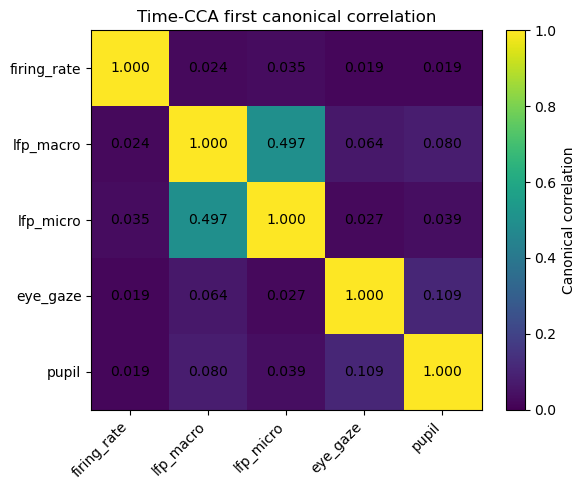

In [32]:
modality_keys = ["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"]

subject_time_pca_res = new_fusion.run_multimodal_subjectwise_time_trajectory_pca(
    concat_data,
    modality_keys=modality_keys,
    n_components=5,
    sub_col="sub",
    standardize=True,
    verbose=True,
)

time_cca_res = new_fusion.compute_pairwise_time_cca_subjectwise(
    subject_time_pca_res,
    modality_keys=modality_keys,
    n_components=3,
    min_windows=10,
    max_iter=2000,
    verbose=True,
)

new_fusion.plot_time_cca_synergy_matrix(
    time_cca_res,
    modality_keys=modality_keys,
    mode="first",
    title="Time-CCA first canonical correlation"
)

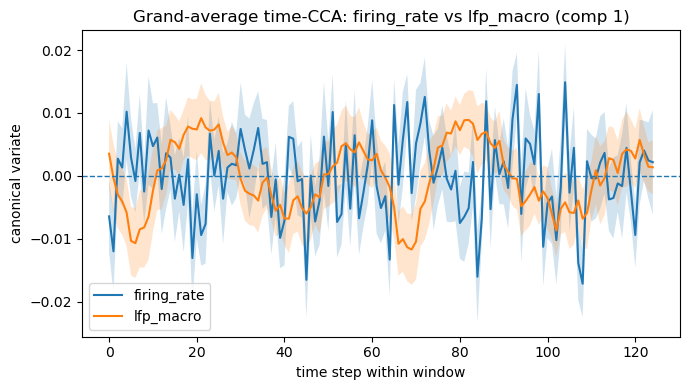

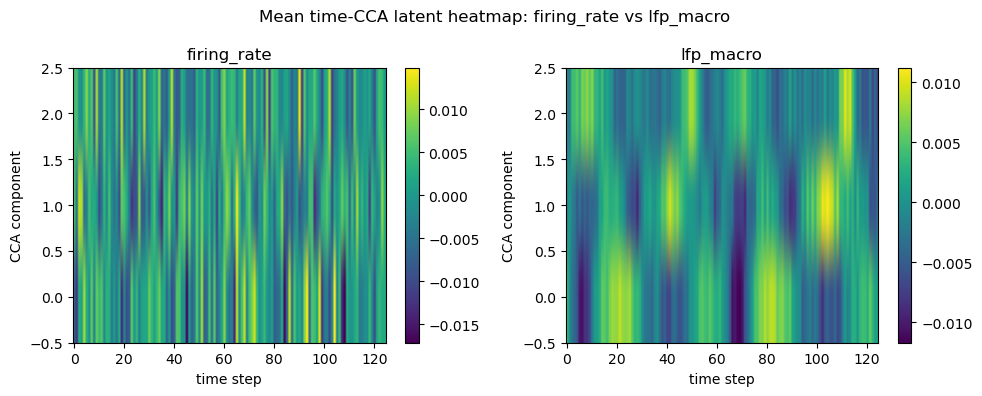

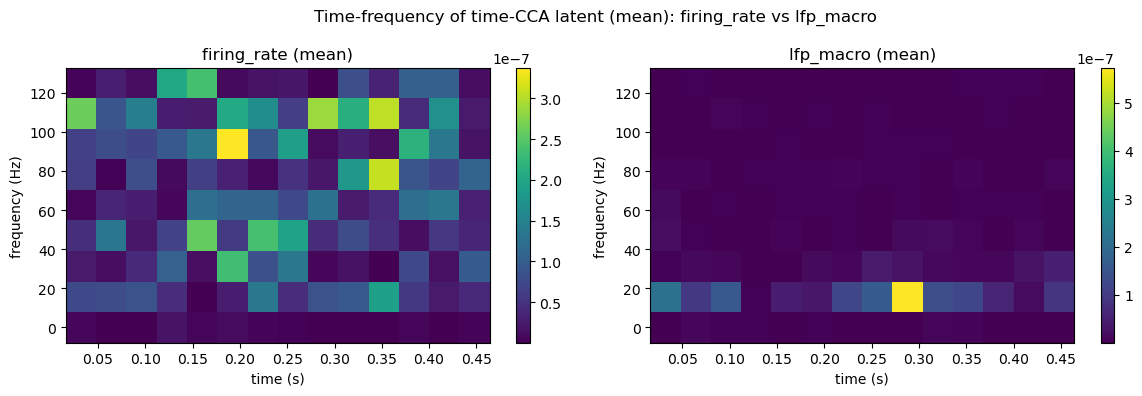

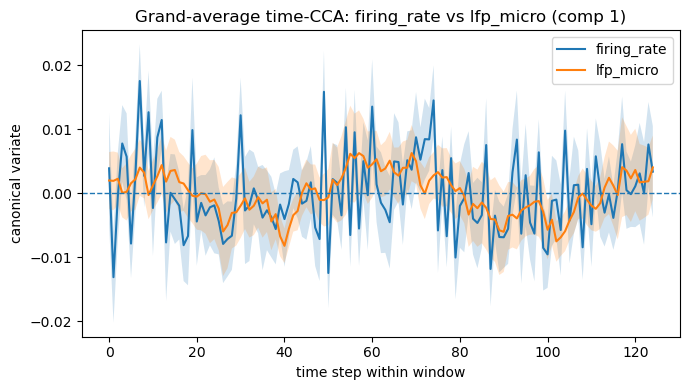

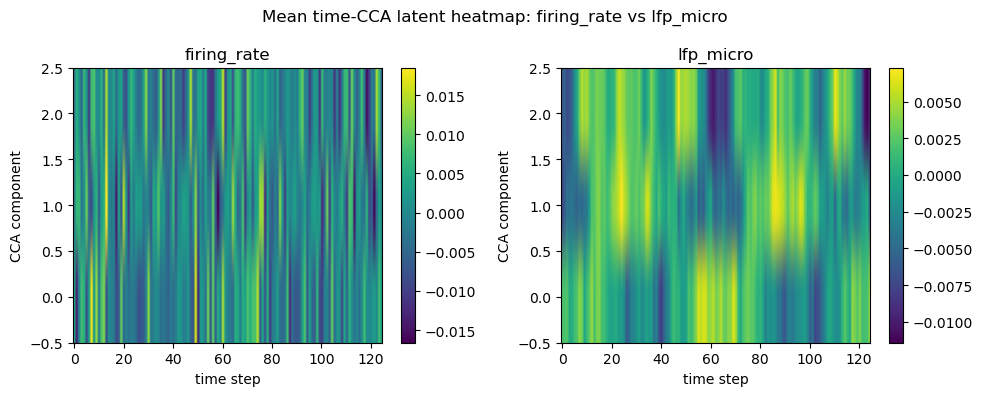

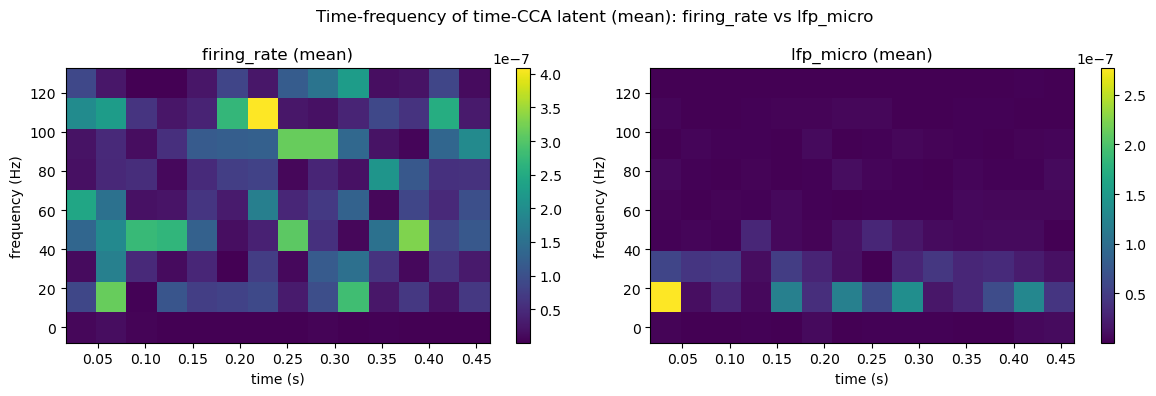

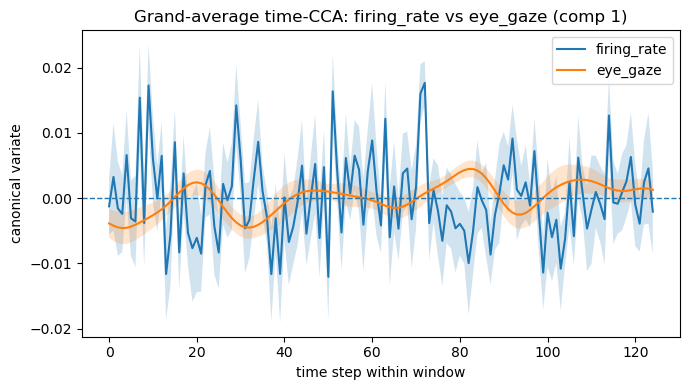

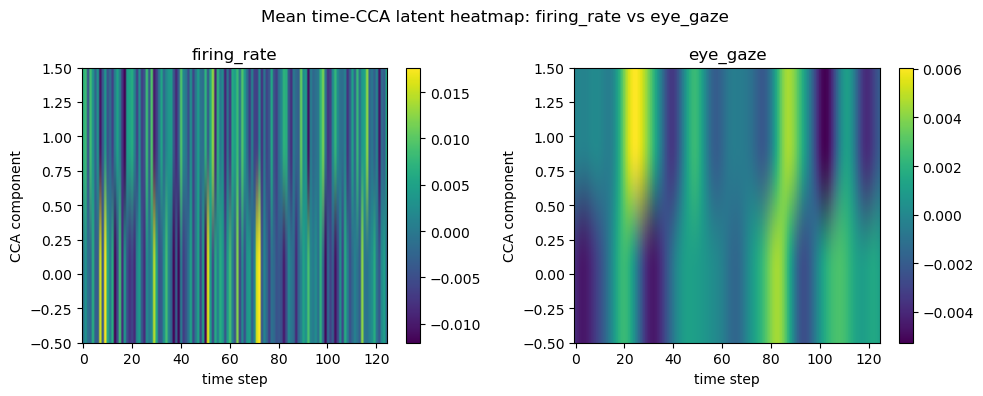

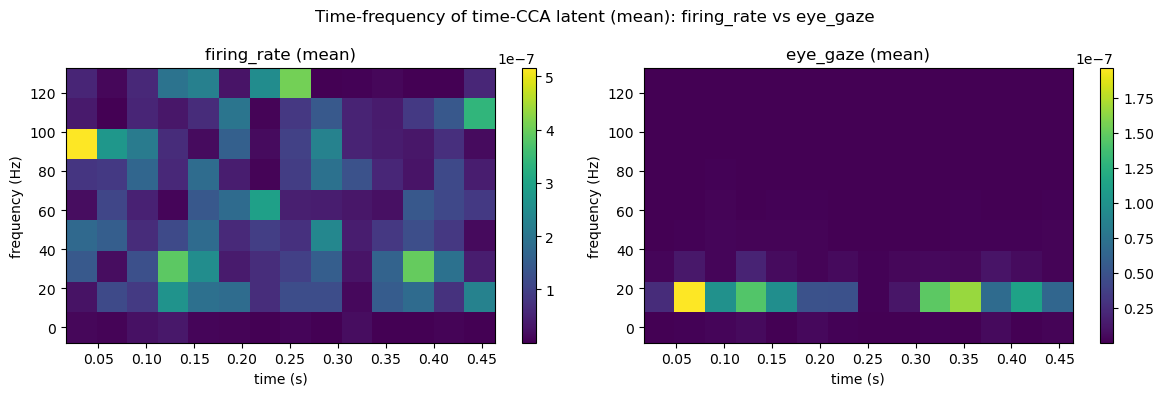

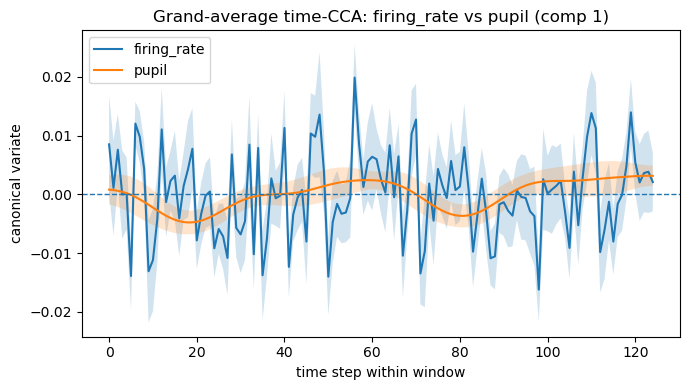

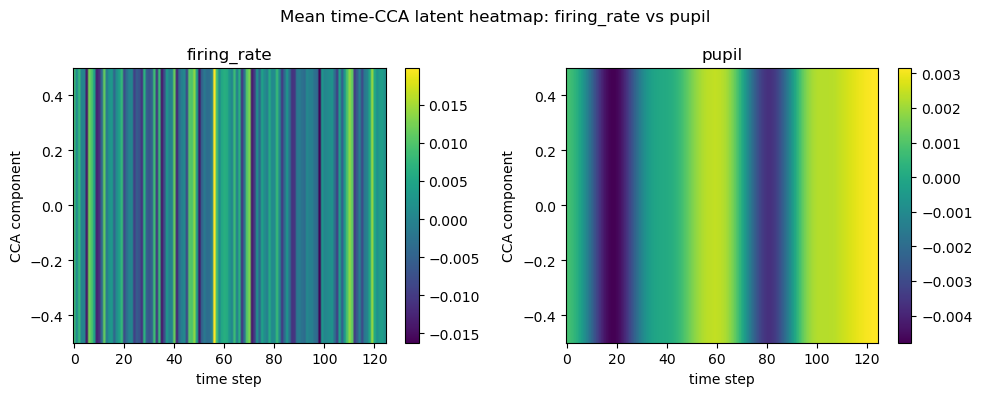

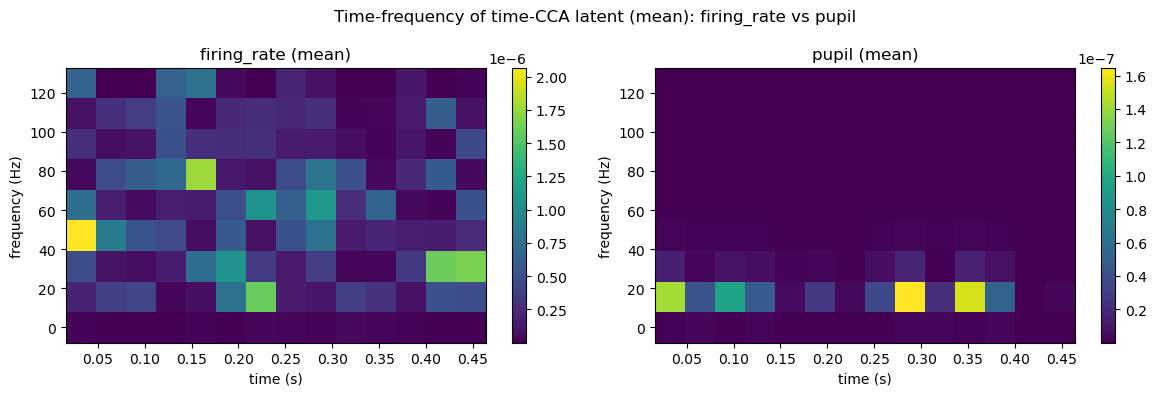

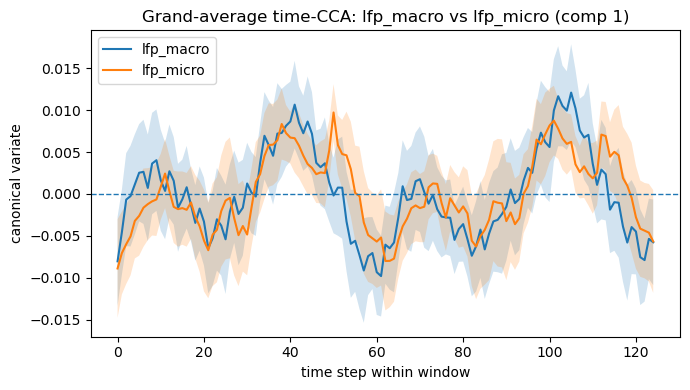

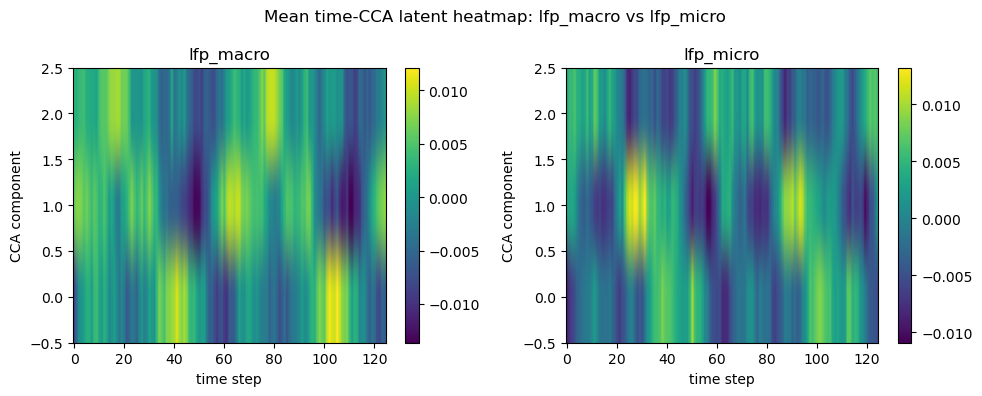

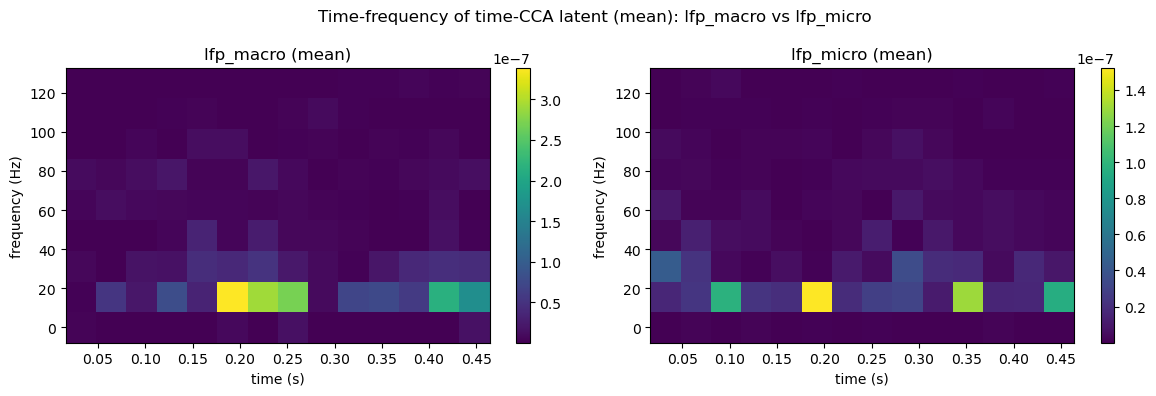

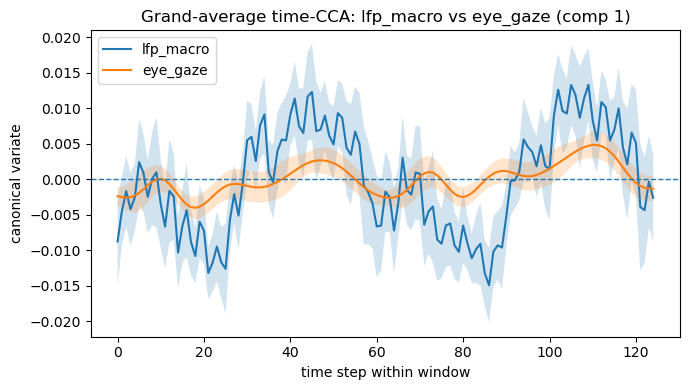

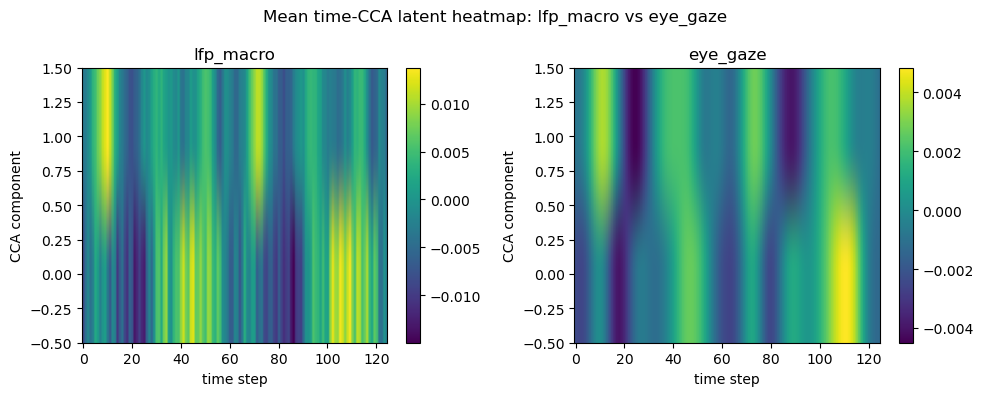

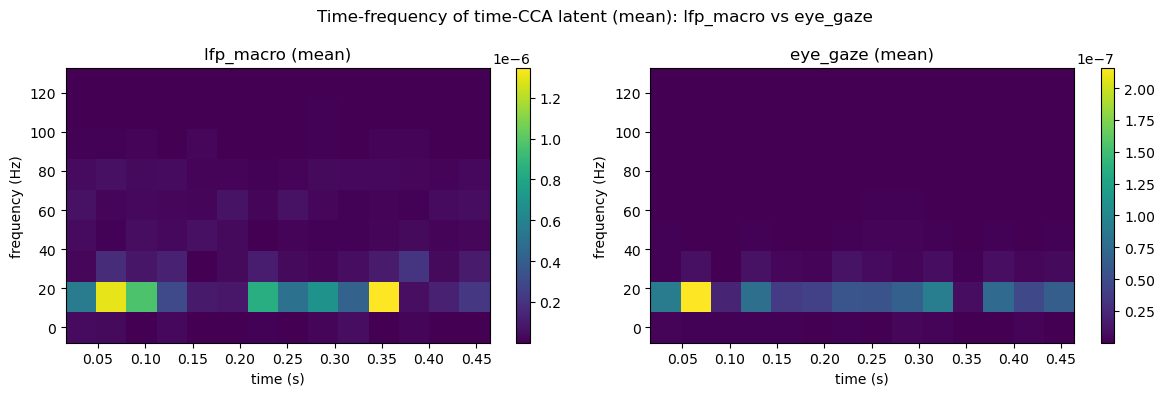

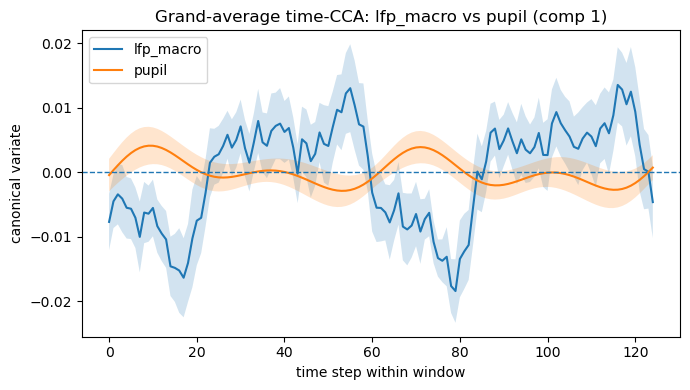

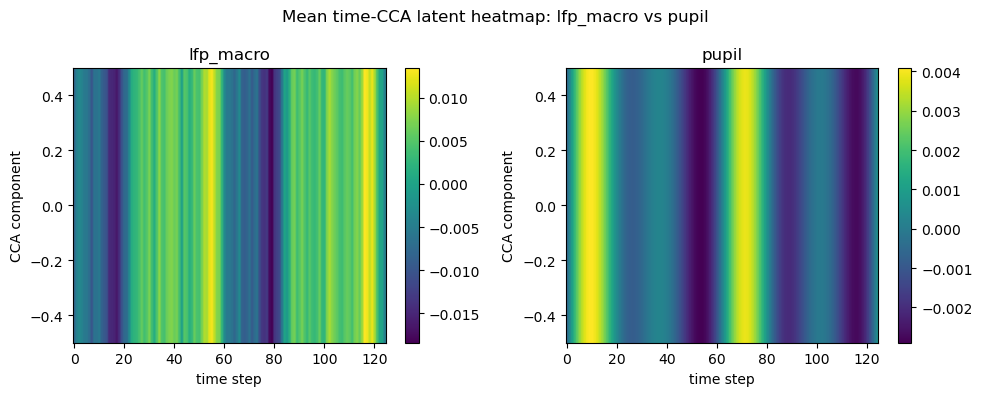

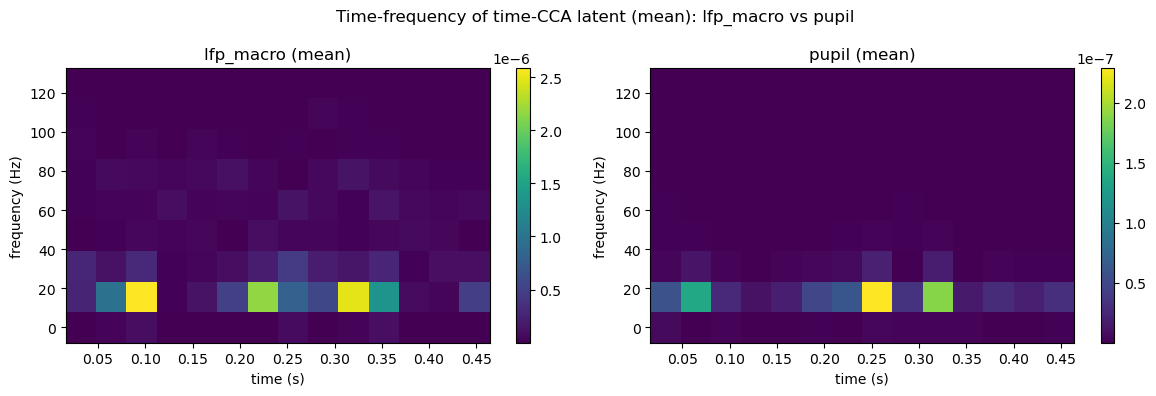

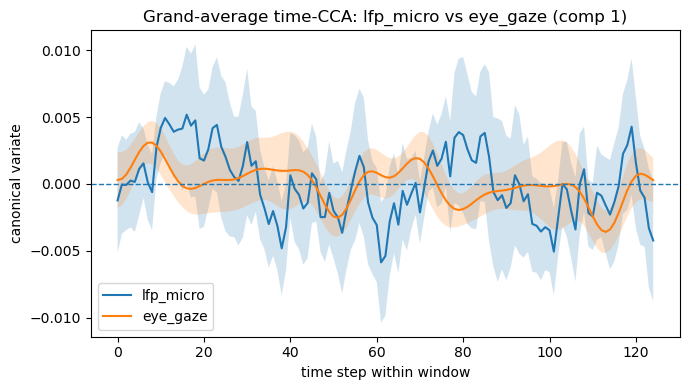

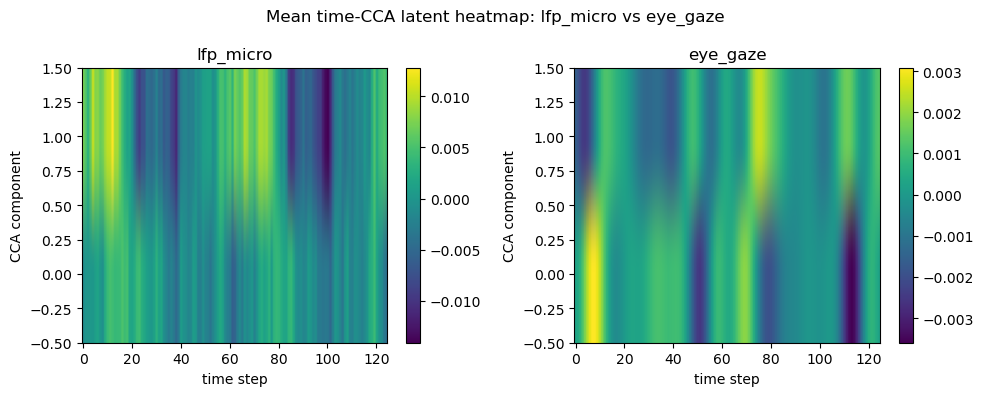

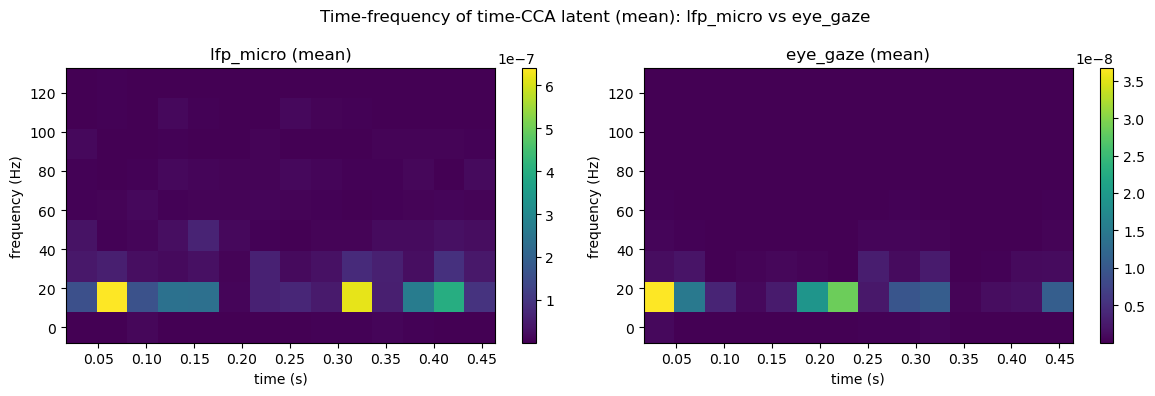

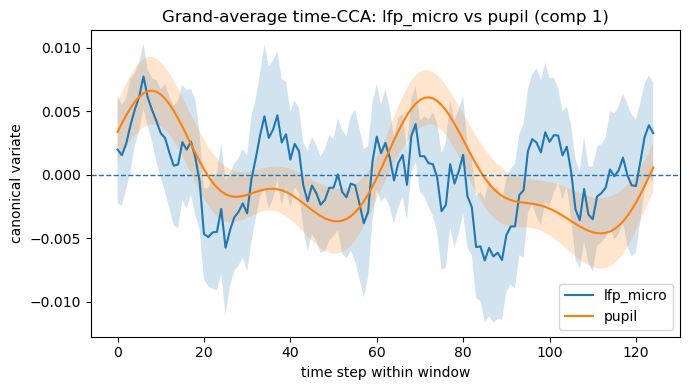

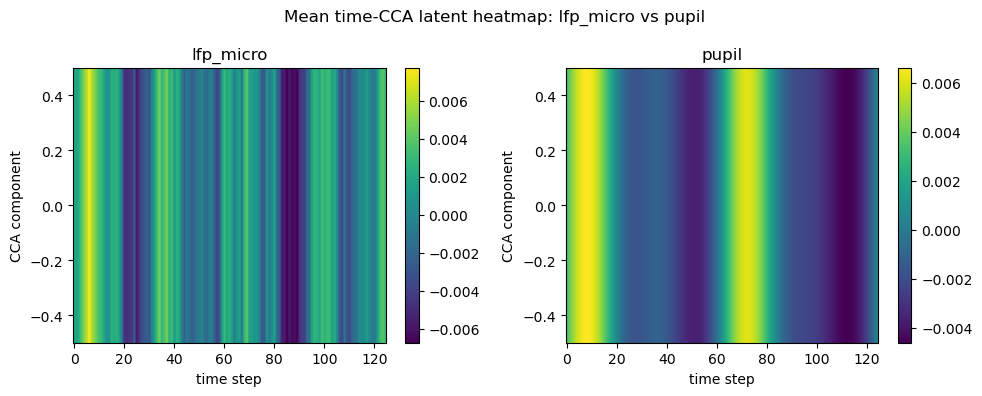

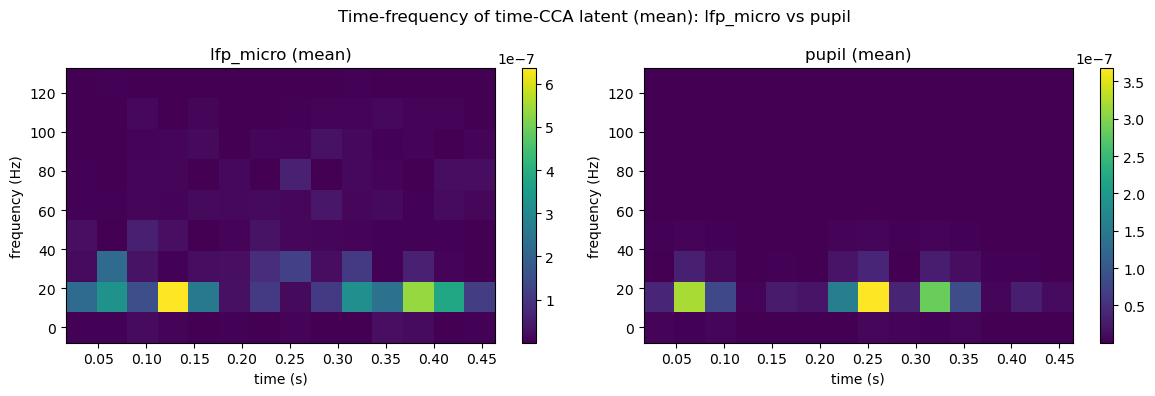

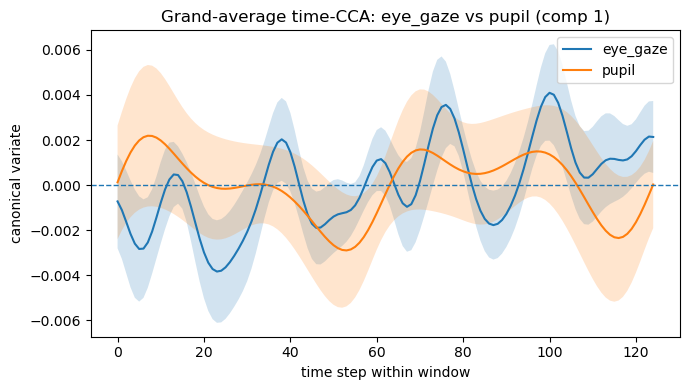

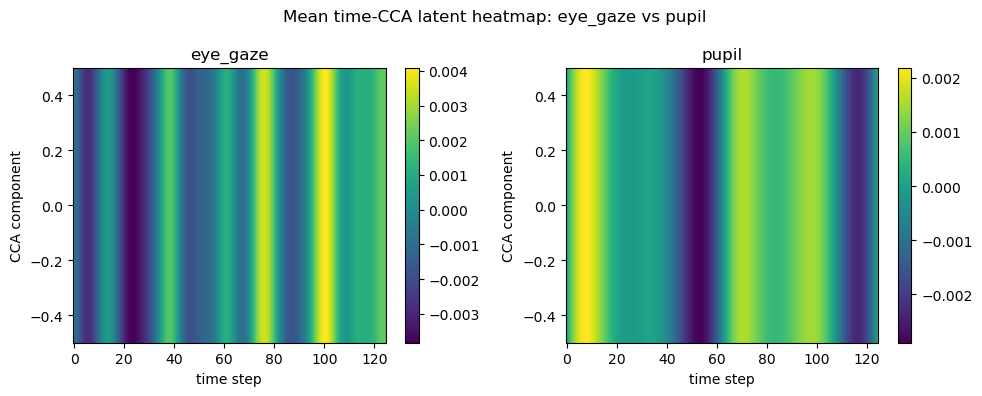

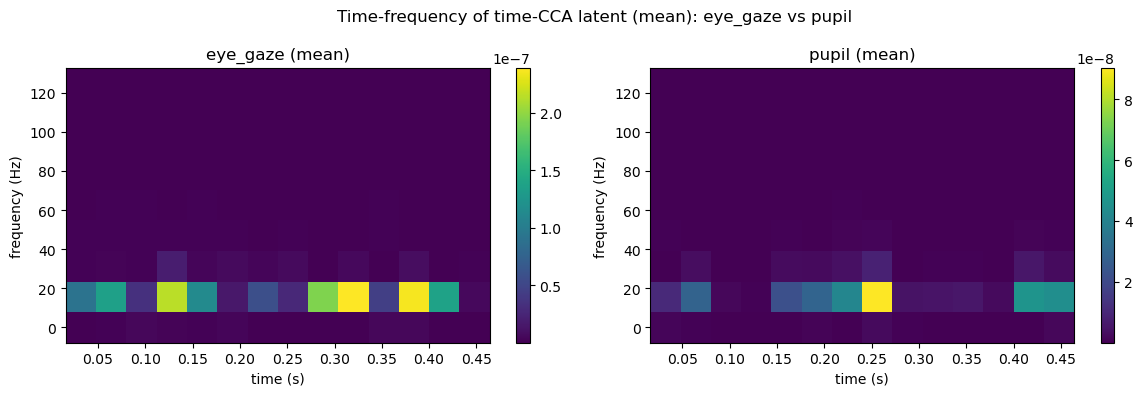

In [33]:
from itertools import combinations

for m1, m2 in combinations(modality_keys, 2):
    new_fusion.plot_time_cca_grandavg_timeseries(
        time_cca_res,
        m1,
        m2,
        comp=0,
        with_sem=True,
    )

    new_fusion.plot_time_cca_mean_timeseries_heatmap(
        time_cca_res,
        m1,
        m2,
    )

    new_fusion.plot_time_cca_latent_spectrogram(
        time_cca_res,
        m1,
        m2,
        feature_mode="mean",
        which="both",
        fs=250,
        nperseg=16,
        noverlap=8,
    )

In [34]:
strong_pairs = [
    ("lfp_macro", "lfp_micro"),
    ("lfp_micro", "eye_gaze"),
    ("lfp_macro", "eye_gaze"),
]

In [35]:
from numpy.linalg import lstsq, eig
from scipy.signal import detrend

def compute_jpca(X, dt):
    """
    X: [T, D]
    dt: scalar
    """
    X = np.asarray(X, dtype=np.float64)

    if X.ndim != 2:
        raise ValueError(f"X must be 2D, got shape={X.shape}")
    if X.shape[0] < 3:
        raise ValueError(f"Need at least 3 time points, got shape={X.shape}")
    if not np.isfinite(dt) or dt <= 0:
        raise ValueError(f"dt must be positive finite, got dt={dt}")

    # 对齐成:
    # X_prev[t] 对应 dX[t] = (X[t+1]-X[t]) / dt
    X_prev = X[:-1]                    # [T-1, D]
    dX = np.diff(X, axis=0) / dt       # [T-1, D]

    # fit: dX = X_prev @ M
    M, _, _, _ = lstsq(X_prev, dX, rcond=None)   # M shape [D, D]

    # 旋转部分
    M_skew = 0.5 * (M - M.T)

    eigvals, eigvecs = eig(M_skew)
    return M, M_skew, eigvals, eigvecs

def project_to_jpca_plane(X, eigvecs, eigvals):
    """
    取虚部最大的那一对特征向量，构造2D jPCA plane
    """
    imag_strength = np.abs(np.imag(eigvals))
    idx = np.argsort(imag_strength)[-2:]

    W = np.real(eigvecs[:, idx])   # [D, 2]
    X_jpca = X @ W                 # [T, 2]
    return X_jpca, W, idx


def plot_jpca_trajectory(X_jpca, modality):
    plt.figure(figsize=(5, 5))
    plt.plot(X_jpca[:, 0], X_jpca[:, 1], linewidth=1)
    plt.scatter(X_jpca[0, 0], X_jpca[0, 1], label="start")
    plt.scatter(X_jpca[-1, 0], X_jpca[-1, 1], label="end")
    plt.xlabel("jPC1")
    plt.ylabel("jPC2")
    plt.title(f"{modality} jPCA plane")
    plt.legend()
    plt.axis("equal")
    plt.show()


def run_jpca_on_result(res, n_input_pc=6):
    X = np.asarray(res["pca_scores"], dtype=np.float64)
    X = detrend(X, axis=0)
    t = np.asarray(res["time"], dtype=np.float64)

    if X.ndim != 2:
        raise ValueError(f"pca_scores must be 2D, got {X.shape}")
    if len(t) != X.shape[0]:
        raise ValueError(f"time length {len(t)} != X rows {X.shape[0]}")
    if len(t) < 3:
        raise ValueError(f"Need at least 3 time points, got {len(t)}")

    # 去掉非有限时间差
    dt_all = np.diff(t)
    dt_all = dt_all[np.isfinite(dt_all) & (dt_all > 0)]
    if len(dt_all) == 0:
        raise ValueError("No valid positive dt found in time axis")
    dt = np.median(dt_all)

    # 限制输入维数
    k = min(n_input_pc, X.shape[1])
    X = X[:, :k]

    # 去掉含nan的行
    good = np.isfinite(X).all(axis=1) & np.isfinite(t)
    X = X[good]
    t = t[good]

    if X.shape[0] < 3:
        raise ValueError(f"Not enough valid rows after cleaning: {X.shape}")

    M, M_skew, eigvals, eigvecs = compute_jpca(X, dt)
    X_jpca, W, idx = project_to_jpca_plane(X, eigvecs, eigvals)

    plot_jpca_trajectory(X_jpca, res["modality"])

    print(f"{res['modality']} | input_dim={k}, T={X.shape[0]}, dt={dt:.6f}")
    print("eigenvalues:", eigvals)
    print("imag parts:", np.imag(eigvals))

    return {
        "X_jpca": X_jpca,
        "eigvals": eigvals,
        "eigvecs": eigvecs,
        "W": W,
        "idx": idx,
        "M": M,
        "M_skew": M_skew,
        "dt": dt,
    }

In [36]:
jpca_results = {}

for modality, res in results.items():
    if res is None:
        continue

    print("\n====", modality, "====")
    try:
        jpca_results[modality] = run_jpca_on_result(res, n_input_pc=6)
    except Exception as e:
        print(f"[skip] {modality}: {e}")

NameError: name 'results' is not defined